# **Install Libraries Required**

In [751]:
# Install the libraries required

!pip install yfinance vaderSentiment xgboost wordcloud statsmodels nltk -q

# **Import the Libraries**

In [752]:
# Import libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

# Visualisation libraries
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Natural language processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Statistical analysis
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

# Machine-learning preprocessing and modelling
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance

# Advanced machine-learning model
from xgboost import XGBRegressor

# Stock-price collection
import yfinance as yf

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Additional text-frequency and sentiment-classification tools

from collections import Counter

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

from sklearn.metrics import ConfusionMatrixDisplay

from xgboost import XGBClassifier

# Used to compare model-training time
import time
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.linear_model import Ridge

from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score
)
# Corrected import: VIF is in statsmodels, not sklearn
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)
print("All libraries imported successfully.")

All libraries imported successfully.


# **Download Resources for Text Preprocessing**

In [753]:
# Download linguistic resources used for text preprocessing
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources downloaded successfully.")

NLTK resources downloaded successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# **Load the Dataset**

In [754]:
# Load the Reddit submissions dataset

file_path = "submissions_reddit.csv"

reddit_df = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset loaded successfully.")
print("Dataset shape:", reddit_df.shape)

reddit_df.head()

Dataset loaded successfully.
Dataset shape: (7130, 24)


,id,author,created,retrieved,edited,pinned,archived,locked,removed,deleted,...,link_flair_text,upvote_ratio,score,gilded,total_awards_received,num_comments,num_crossposts,selftext,thumbnail,shortlink
0,ko3ecd,bighlovd,2021-01-01 02:33:23,2021-02-04 06:28:30,1970-01-01 00:00:00,0,0,0,1,0,...,NaN,0.50,0,0,0,0,0,NaN,default,https://redd.it/ko3ecd
1,ko4jed,naturalhighguy,2021-01-01 03:56:40,2021-02-04 06:28:30,1970-01-01 00:00:00,0,0,0,1,0,...,NaN,0.38,0,0,0,11,0,NaN,default,https://redd.it/ko4jed
2,ko65fk,Venky2310,2021-01-01 05:55:12,2021-02-04 06:28:30,1970-01-01 00:00:00,0,0,0,1,0,...,NaN,1.00,1,0,0,0,0,NaN,default,https://redd.it/ko65fk
3,koaw8g,[deleted],2021-01-01 12:57:48,2021-02-04 06:28:30,1970-01-01 00:00:00,0,0,0,1,1,...,NaN,1.00,1,0,0,0,0,[deleted],default,https://redd.it/koaw8g
4,kobbka,fintechinshorts,2021-01-01 13:31:53,2021-02-04 06:28:30,1970-01-01 00:00:00,0,0,0,1,0,...,NaN,1.00,1,0,0,0,0,NaN,default,https://redd.it/kobbka


# **Initial Dataset Inspection**

In [755]:
# Initial Dataset Inspection
print("Column names:")
print(reddit_df.columns.tolist())

print("\nDataset information:")
reddit_df.info()

Column names:
['id', 'author', 'created', 'retrieved', 'edited', 'pinned', 'archived', 'locked', 'removed', 'deleted', 'is_self', 'is_video', 'is_original_content', 'title', 'link_flair_text', 'upvote_ratio', 'score', 'gilded', 'total_awards_received', 'num_comments', 'num_crossposts', 'selftext', 'thumbnail', 'shortlink']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7130 entries, 0 to 7129
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     7130 non-null   object 
 1   author                 7130 non-null   object 
 2   created                7130 non-null   object 
 3   retrieved              7130 non-null   object 
 4   edited                 7130 non-null   object 
 5   pinned                 7130 non-null   int64  
 6   archived               7130 non-null   int64  
 7   locked                 7130 non-null   int64  
 8   removed              

# **Data Quality Assessment**

In [756]:
# Calculate missing values and percentages for every variable

missing_summary = pd.DataFrame({
    "Missing_Count": reddit_df.isnull().sum(),
    "Missing_Percentage": (
        reddit_df.isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
link_flair_text,7130,100.00
selftext,6534,91.64
id,0,0.00
author,0,0.00
edited,0,0.00
pinned,0,0.00
created,0,0.00
retrieved,0,0.00
locked,0,0.00
archived,0,0.00


In [757]:
# Check duplicate rows and duplicate Reddit post IDs

exact_duplicates = reddit_df.duplicated().sum()
duplicate_ids = reddit_df["id"].duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)
print("Duplicate post IDs:", duplicate_ids)

Exact duplicate rows: 0
Duplicate post IDs: 0


In [758]:
# Examine duplicate titles and repeated textual content

duplicate_title_count = reddit_df.duplicated(
    subset=["title"],
    keep=False
).sum()

print("Records belonging to duplicate-title groups:", duplicate_title_count)

# Display the most frequently repeated titles
repeated_titles = (
    reddit_df["title"]
    .fillna("")
    .value_counts()
    .reset_index()
)

repeated_titles.columns = [
    "Title",
    "Frequency"
]

repeated_titles = repeated_titles[
    (repeated_titles["Title"].str.strip() != "") &
    (repeated_titles["Frequency"] > 1)
]

repeated_titles.head(15)

Records belonging to duplicate-title groups: 428


,Title,Frequency
0,Real Estate Diary,8
1,FOREX - FortuneZ,8
2,Joe Biden Tax Explained: What You Should Know.,7
3,How To Create & Manage Your Personal Wealth | ...,5
4,HAI Listing on a Top Exchange — DONE!,5
5,The new 401K Plan: How to get started.,4
6,Mortgage Broker In Foster City,4
7,I wrote some code to generate a daily report o...,4
8,Seguro de vida con beneficios de vida en Miami,4
9,How The COVID-19 Pandemic Reshaped The Health ...,3


In [759]:
# Display examples of repeated titles.

if not repeated_titles.empty:

    repeated_title_examples = reddit_df[
        reddit_df["title"].isin(
            repeated_titles["Title"].head(10)
        )
    ][
        [
            "id",
            "created",
            "title",
            "score",
            "num_comments"
        ]
    ].sort_values(
        by="title"
    )

    display(repeated_title_examples.head(30))

else:
    print("No repeated non-empty titles were identified.")

,id,created,title,score,num_comments
2405,nctqas,2021-05-15 08:06:27,FOREX - FortuneZ,1,0
2400,nctns1,2021-05-15 08:01:33,FOREX - FortuneZ,1,0
2459,nf3068,2021-05-18 06:14:34,FOREX - FortuneZ,1,0
2401,nctogl,2021-05-15 08:02:51,FOREX - FortuneZ,1,0
2458,nf2zja,2021-05-18 06:13:34,FOREX - FortuneZ,1,0
2402,nctozv,2021-05-15 08:03:55,FOREX - FortuneZ,1,0
2404,nctpwi,2021-05-15 08:05:47,FOREX - FortuneZ,1,0
2403,nctpi8,2021-05-15 08:04:58,FOREX - FortuneZ,1,0
1913,mws3bv,2021-04-23 10:16:52,HAI Listing on a Top Exchange — DONE!,1,0
1910,mwjlhv,2021-04-23 01:03:15,HAI Listing on a Top Exchange — DONE!,1,0


In [760]:
# Remove exact title duplicates
records_before_text_deduplication = len(reddit_df)

reddit_df = reddit_df.drop_duplicates(
    subset=["title"],
    keep="first"
).copy()

records_after_text_deduplication = len(reddit_df)

print(
    "Records removed due to exact duplicate titles:",
    records_before_text_deduplication
    - records_after_text_deduplication
)

print(
    "Dataset shape after textual duplicate removal:",
    reddit_df.shape
)

Records removed due to exact duplicate titles: 241
Dataset shape after textual duplicate removal: (6889, 24)


In [761]:
# Retain only one record for each Reddit post ID

reddit_df = reddit_df.drop_duplicates(
    subset="id",
    keep="first"
).copy()

print("Shape after duplicate removal:", reddit_df.shape)

Shape after duplicate removal: (6889, 24)


# **Text Preparation and Preprocessing**

In [762]:
# Convert the post-creation field into a valid datetime format

reddit_df["created"] = pd.to_datetime(
    reddit_df["created"],
    errors="coerce"
)

# Remove records where the creation date cannot be interpreted
reddit_df = reddit_df.dropna(
    subset=["created"]
).copy()

# Extract calendar features for exploratory analysis
reddit_df["date"] = reddit_df["created"].dt.normalize()
reddit_df["year"] = reddit_df["created"].dt.year
reddit_df["month"] = reddit_df["created"].dt.month
reddit_df["month_name"] = reddit_df["created"].dt.month_name()
reddit_df["day_of_week"] = reddit_df["created"].dt.day_name()
reddit_df["hour"] = reddit_df["created"].dt.hour

print("Earliest post:", reddit_df["created"].min())
print("Latest post:", reddit_df["created"].max())

Earliest post: 2021-01-01 02:33:23
Latest post: 2021-12-31 23:35:09


In [763]:
# Convert status fields to numeric values where necessary

status_columns = [
    "removed",
    "deleted",
    "pinned",
    "archived",
    "locked"
]

for column in status_columns:
    reddit_df[column] = pd.to_numeric(
        reddit_df[column],
        errors="coerce"
    ).fillna(0)

# Keep posts that were not marked as removed or deleted
# Retain posts when the title remains available.
# Exclude only records whose usable text is explicitly deleted or empty.

analysis_df = reddit_df.copy()

analysis_df["title"] = (
    analysis_df["title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

analysis_df["selftext"] = (
    analysis_df["selftext"]
    .fillna("")
    .astype(str)
    .str.strip()
)

analysis_df = analysis_df[
    ~analysis_df["title"].str.lower().isin(
        ["", "[deleted]", "[removed]"]
    )
].copy()

print("Records retained:", len(analysis_df))

print("Original records:", len(reddit_df))
print("Records retained for analysis:", len(analysis_df))
print("Records excluded:", len(reddit_df) - len(analysis_df))

Records retained: 6889
Original records: 6889
Records retained for analysis: 6889
Records excluded: 0


In [764]:
# Remove unavailable body-text markers before combining text

unavailable_markers = {
    "[deleted]",
    "[removed]",
    "deleted",
    "removed"
}

analysis_df.loc[
    analysis_df["selftext"]
    .str.lower()
    .isin(unavailable_markers),
    "selftext"
] = ""

analysis_df["raw_text"] = (
    analysis_df["title"].str.strip()
    + " "
    + analysis_df["selftext"].str.strip()
)

analysis_df["raw_text"] = (
    analysis_df["raw_text"]
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

analysis_df = analysis_df[
    analysis_df["raw_text"].str.len() > 0
].copy()

In [765]:
# Prepare stop words and lemmatisation

stop_words = set(stopwords.words("english"))

# Keep negation terms because they affect financial sentiment
negation_words = {
    "not",
    "no",
    "nor",
    "against"
}

stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """
    Clean Reddit text while preserving useful sentiment information.

    Processing includes:
    1. Lowercasing
    2. Removing URLs
    3. Removing Reddit user and subreddit references
    4. Removing HTML entities
    5. Removing non-alphabetic symbols
    6. Removing low-information stop words
    7. Lemmatization
    """

    # Convert input safely to a string
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove Reddit-specific references
    text = re.sub(r"\br/\w+\b", " ", text)
    text = re.sub(r"\bu/\w+\b", " ", text)

    # Remove HTML entities
    text = re.sub(r"&\w+;", " ", text)

    # Remove non-alphabetical characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenise, remove stop words and lemmatise
    tokens = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

In [766]:
# Apply the cleaning function to every Reddit submission

analysis_df["clean_text"] = analysis_df["raw_text"].apply(
    clean_text
)

# Remove records that become empty after cleaning
analysis_df = analysis_df[
    analysis_df["clean_text"].str.len() > 0
].copy()

# Create basic textual features
analysis_df["word_count"] = (
    analysis_df["clean_text"]
    .str.split()
    .str.len()
)

analysis_df["character_count"] = (
    analysis_df["clean_text"]
    .str.len()
)

analysis_df[
    ["raw_text", "clean_text", "word_count"]
].head()

,raw_text,clean_text,word_count
0,click this link to make free sign up!!!,click link make free sign,5
1,How often do people voluntarily pay back the g...,often people voluntarily pay back government u...,16
2,Need some business and financial articles to e...,need business financial article enhance websit...,7
3,Tech's top seven companies added $3.4 trillion...,tech top seven company added trillion value,7
4,Mogo: Establishes ATM Equity Program Mogo a fi...,mogo establishes atm equity program mogo finan...,13


In [767]:
# Summarise the cleaned textual variables

print(
    analysis_df[
        ["word_count", "character_count"]
    ].describe()
)

print("\nExample original text:\n")
print(analysis_df["raw_text"].iloc[0])

print("\nExample cleaned text:\n")
print(analysis_df["clean_text"].iloc[0])

        word_count  character_count
count  6865.000000      6865.000000
mean      8.772760        64.202331
std       5.244871        42.583967
min       1.000000         3.000000
25%       5.000000        35.000000
50%       8.000000        52.000000
75%      11.000000        85.000000
max      37.000000       273.000000

Example original text:

click this link to make free sign up!!!

Example cleaned text:

click link make free sign


In [768]:
# Identify posts containing fewer than three cleaned words.
# Very short records often contain insufficient linguistic information
# for dependable sentiment interpretation.

short_text_threshold = 3

very_short_posts = analysis_df[
    analysis_df["word_count"] < short_text_threshold
].copy()

print(
    "Number of posts with fewer than",
    short_text_threshold,
    "cleaned words:",
    len(very_short_posts)
)

print(
    "Percentage of very short posts:",
    round(
        len(very_short_posts)
        / len(analysis_df)
        * 100,
        2
    ),
    "%"
)

very_short_posts[
    [
        "title",
        "clean_text",
        "word_count"
    ]
].head(20)

Number of posts with fewer than 3 cleaned words: 341
Percentage of very short posts: 4.97 %


,title,clean_text,word_count
31,25$ airdrop on Telegram,airdrop telegram,2
47,nCino Analysis,ncino analysis,2
54,Happy Lohri,happy lohri,2
105,Help please,help please,2
111,Free stocks,free stock,2
120,What is Decentralized Finance?,decentralized finance,2
219,Netflix latest 10-Q,netflix latest,2
225,The SPAC Revolution,spac revolution,2
271,strawberries on the blockchain,strawberry blockchain,2
277,GM’s New Groove,new groove,2


In [769]:
# Retain posts containing at least three cleaned words.
# This improves the reliability of frequency analysis and TF-IDF features.

records_before_short_text_removal = len(analysis_df)

analysis_df = analysis_df[
    analysis_df["word_count"] >= short_text_threshold
].copy()

print(
    "Very short posts removed:",
    records_before_short_text_removal
    - len(analysis_df)
)

print(
    "Records retained:",
    len(analysis_df)
)

Very short posts removed: 341
Records retained: 6524


In [770]:
# Convert engagement variables into numeric form

engagement_columns = [
    "score",
    "upvote_ratio",
    "num_comments",
    "num_crossposts",
    "gilded",
    "total_awards_received"
]

for column in engagement_columns:
    analysis_df[column] = pd.to_numeric(
        analysis_df[column],
        errors="coerce"
    ).fillna(0)

# Prevent negative scores from causing logarithm errors
analysis_df["score_nonnegative"] = (
    analysis_df["score"].clip(lower=0)
)

analysis_df["comments_nonnegative"] = (
    analysis_df["num_comments"].clip(lower=0)
)

# Log transformation reduces the effect of extremely popular posts
analysis_df["log_score"] = np.log1p(
    analysis_df["score_nonnegative"]
)

analysis_df["log_comments"] = np.log1p(
    analysis_df["comments_nonnegative"]
)

analysis_df[
    [
        "score",
        "num_comments",
        "upvote_ratio",
        "log_score",
        "log_comments"
    ]
].describe()

,score,num_comments,upvote_ratio,log_score,log_comments
count,6524.000000,6524.000000,6524.000000,6524.000000,6524.000000
mean,34.868179,5.549203,0.943716,1.296177,0.514872
std,177.400641,23.900553,0.144067,1.509407,1.134324
min,0.000000,0.000000,0.070000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,0.693147,0.000000
50%,1.000000,0.000000,1.000000,0.693147,0.000000
75%,1.000000,0.000000,1.000000,0.693147,0.000000
max,9348.000000,505.000000,1.000000,9.143025,6.226537


# **Exploratory Data Analysis**

In [771]:
# Generate descriptive statistics for important variables

descriptive_statistics = analysis_df[
    [
        "score",
        "upvote_ratio",
        "num_comments",
        "num_crossposts",
        "word_count"
    ]
].describe().T

descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
score,6524.0,34.868179,177.400641,0.00,1.0,1.0,1.0,9348.0
upvote_ratio,6524.0,0.943716,0.144067,0.07,1.0,1.0,1.0,1.0
num_comments,6524.0,5.549203,23.900553,0.00,0.0,0.0,0.0,505.0
num_crossposts,6524.0,0.056714,0.298449,0.00,0.0,0.0,0.0,5.0
word_count,6524.0,9.140405,5.120073,3.00,6.0,8.0,12.0,37.0


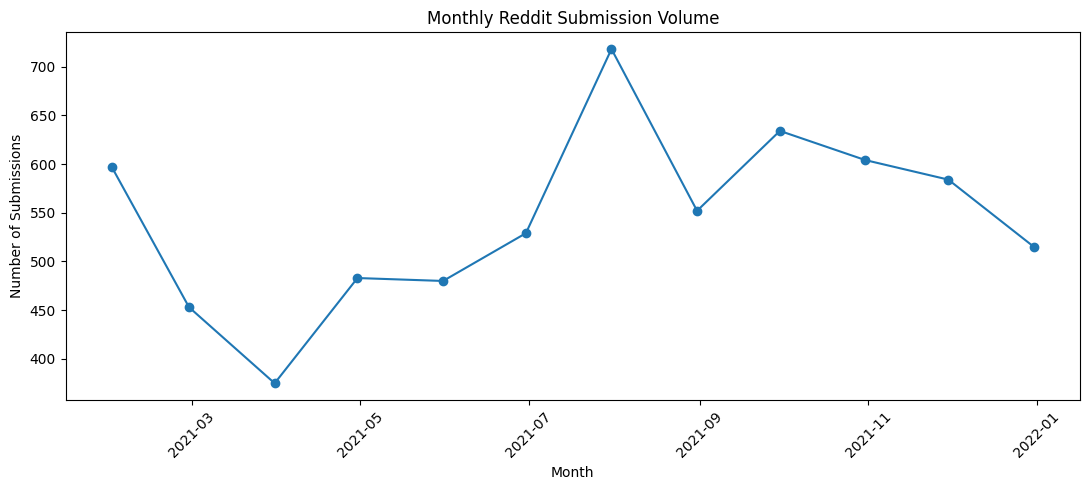

In [772]:
# Count the number of Reddit submissions in each month

monthly_volume = (
    analysis_df
    .set_index("created")
    .resample("M")
    .size()
)

plt.figure(figsize=(11, 5))
plt.plot(
    monthly_volume.index,
    monthly_volume.values,
    marker="o"
)

plt.title("Monthly Reddit Submission Volume")
plt.xlabel("Month")
plt.ylabel("Number of Submissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

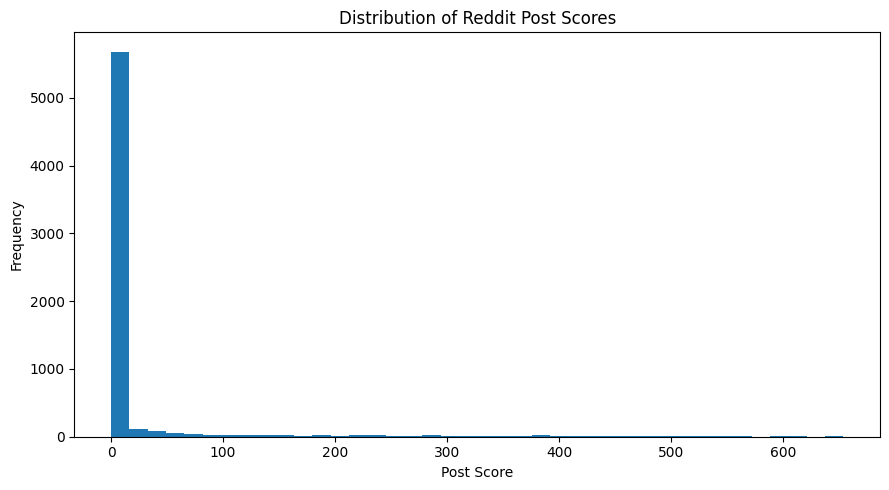

In [773]:
# Display score distribution after limiting the plot to the 99th percentile
# This prevents a few extreme posts from making the graph unreadable.

score_limit = analysis_df["score"].quantile(0.99)

plt.figure(figsize=(9, 5))
plt.hist(
    analysis_df.loc[
        analysis_df["score"] <= score_limit,
        "score"
    ],
    bins=40
)

plt.title("Distribution of Reddit Post Scores")
plt.xlabel("Post Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [774]:
# Combine all cleaned posts and count individual words

all_tokens = []

for text in analysis_df["clean_text"].dropna():
    all_tokens.extend(text.split())

word_frequency = Counter(all_tokens)

top_words = pd.DataFrame(
    word_frequency.most_common(25),
    columns=[
        "Word",
        "Frequency"
    ]
)

top_words

,Word,Frequency
0,fintechinshorts,1084
1,fintechnews,1084
2,stock,392
3,market,379
4,finance,363
5,bank,353
6,new,348
7,financial,324
8,money,241
9,launch,239


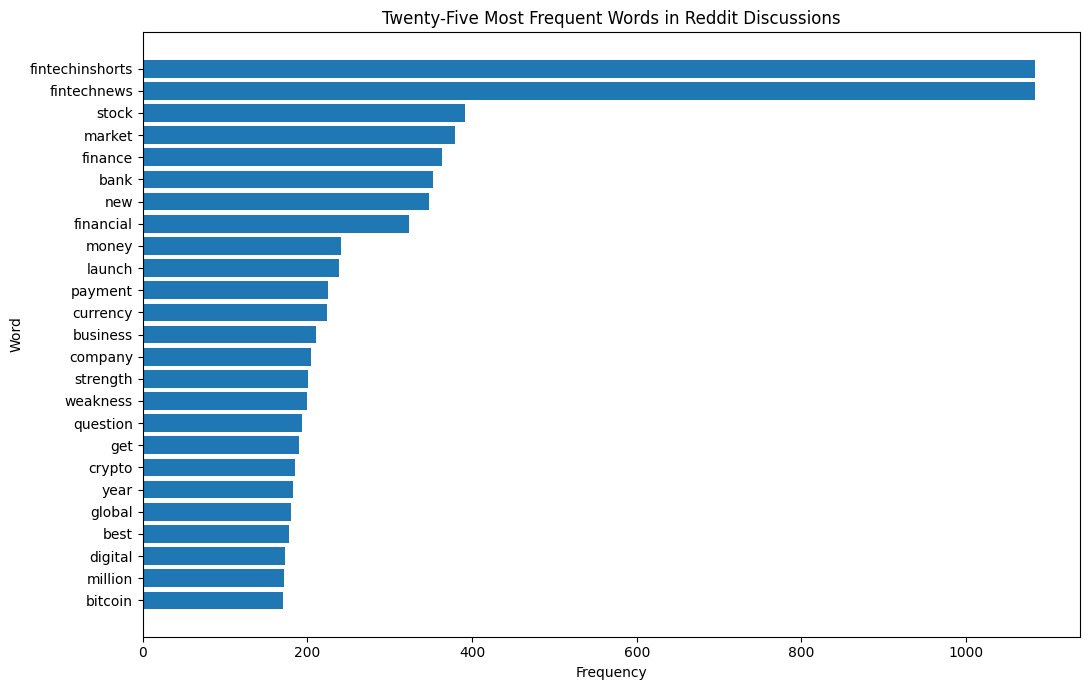

In [775]:
# Visualise the most common terms in the complete Reddit corpus

plt.figure(figsize=(11, 7))

plt.barh(
    top_words["Word"][::-1],
    top_words["Frequency"][::-1]
)

plt.title("Twenty-Five Most Frequent Words in Reddit Discussions")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

In [776]:
# Financial discussion contains common terms that may be frequent
# but provide limited discriminating information.

domain_stop_words = {
    "stock", "market", "company", "share",
    "price", "buy", "sell", "year",
    "day", "today", "week", "money",
    "reddit", "finance", "financial",

    "question", "thread", "general",
    "reply", "career", "homework",
    "problem", "domain", "constructive",
    "civil", "unwelcome", "belong",
    "monday", "weekly", "also",
    "place", "encouraged",

    "deleted", "removed",
    "fintechinshorts", "fintechnews"
}


def remove_domain_stop_words(text):
    """
    Remove high-frequency domain words that provide limited
    discriminatory value in thematic frequency analysis.
    """

    tokens = str(text).split()

    filtered_tokens = [
        token
        for token in tokens
        if token not in domain_stop_words
    ]

    return " ".join(filtered_tokens)


analysis_df["refined_clean_text"] = (
    analysis_df["clean_text"]
    .apply(remove_domain_stop_words)
)

analysis_df[
    [
        "clean_text",
        "refined_clean_text"
    ]
].head()

,clean_text,refined_clean_text
0,click link make free sign,click link make free sign
1,often people voluntarily pay back government u...,often people voluntarily pay back government u...
2,need business financial article enhance websit...,need business article enhance website check
3,tech top seven company added trillion value,tech top seven added trillion value
4,mogo establishes atm equity program mogo finan...,mogo establishes atm equity program mogo techn...


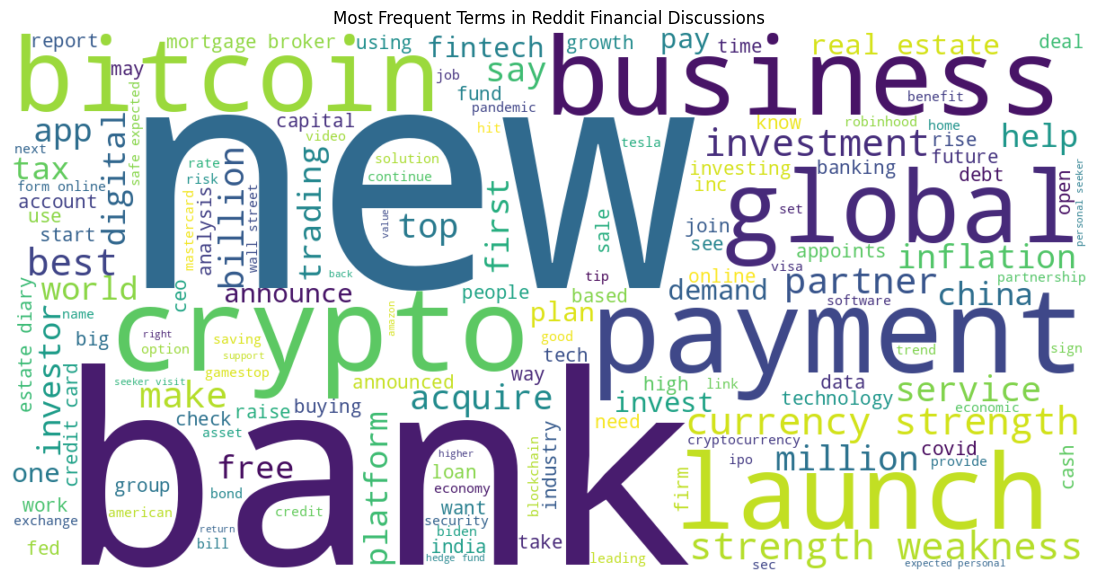

In [777]:
# Combine cleaned Reddit text into one corpus

all_clean_text = " ".join(
    analysis_df["refined_clean_text"].dropna()
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150
).generate(all_clean_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Terms in Reddit Financial Discussions")
plt.show()

In [778]:
# A bigram is a sequence of two consecutive words.
# Bigrams reveal phrases that single-word analysis may overlook.

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=2,
    max_features=1000
)

bigram_matrix = bigram_vectorizer.fit_transform(
    analysis_df["refined_clean_text"]
)

bigram_frequencies = np.asarray(
    bigram_matrix.sum(axis=0)
).flatten()

bigram_terms = (
    bigram_vectorizer
    .get_feature_names_out()
)

top_bigrams = pd.DataFrame({
    "Bigram": bigram_terms,
    "Frequency": bigram_frequencies
}).sort_values(
    by="Frequency",
    ascending=False
).head(20)

top_bigrams

,Bigram,Frequency
257,currency strength,156
896,strength weakness,156
754,real estate,92
571,mortgage broker,81
335,estate diary,63
242,credit card,58
376,form online,47
960,wall street,47
795,safe expected,44
700,personal seeker,44


## **Target-Stock Identification**

In [779]:
# Define stock ticker symbols and associated text expressions

stock_patterns = {
    "TSLA": r"\b(?:tsla|tesla)\b",
    "GME": r"\b(?:gme|gamestop|game stop)\b",
    "GOOGL": r"\b(?:googl|goog|google|alphabet)\b",
    "AMZN": r"\b(?:amzn|amazon)\b",
    "META": r"\b(?:meta|facebook|fb)\b",
    "AAPL": r"\b(?:aapl|apple)\b"
}

# Count how often each company appears in the original text
stock_mention_counts = {}

for ticker, pattern in stock_patterns.items():
    count = analysis_df["raw_text"].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False
    ).sum()

    stock_mention_counts[ticker] = count

stock_mention_table = (
    pd.DataFrame.from_dict(
        stock_mention_counts,
        orient="index",
        columns=["Mention_Count"]
    )
    .sort_values(
        by="Mention_Count",
        ascending=False
    )
)

stock_mention_table

,Mention_Count
GME,67
TSLA,42
GOOGL,42
AMZN,40
META,32
AAPL,25


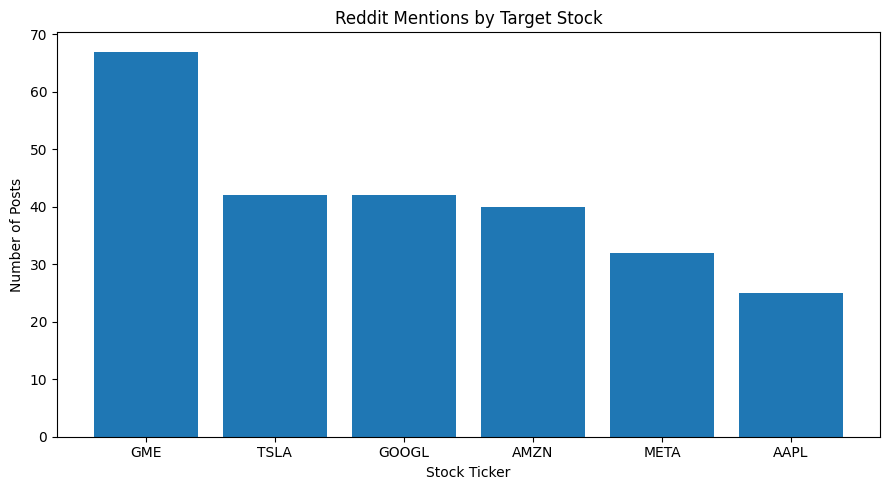

In [780]:
# Plot the number of posts mentioning each selected stock

plt.figure(figsize=(9, 5))
plt.bar(
    stock_mention_table.index,
    stock_mention_table["Mention_Count"]
)

plt.title("Reddit Mentions by Target Stock")
plt.xlabel("Stock Ticker")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

In [781]:
def identify_stocks(text):
    """
    Return all stock tickers mentioned in a Reddit post.
    """

    mentioned_stocks = []

    for ticker, pattern in stock_patterns.items():
        if re.search(pattern, str(text), flags=re.IGNORECASE):
            mentioned_stocks.append(ticker)

    return mentioned_stocks


# Detect stock references in every post
analysis_df["mentioned_stocks"] = (
    analysis_df["raw_text"].apply(identify_stocks)
)

# Retain only posts that discuss at least one target company
stock_posts = analysis_df[
    analysis_df["mentioned_stocks"].str.len() > 0
].copy()

# Create one row for every post-stock pair
stock_posts = stock_posts.explode(
    "mentioned_stocks"
).rename(
    columns={"mentioned_stocks": "ticker"}
)

print("Stock-related post-record pairs:", len(stock_posts))

stock_posts[
    ["created", "ticker", "title"]
].head()

Stock-related post-record pairs: 248


,created,ticker,title
12,2021-01-02 10:00:43,TSLA,Tesla market cap and revenue compared to 10 la...
41,2021-01-04 10:54:00,TSLA,Tesla shares set to start 2021 at record high
73,2021-01-05 16:06:43,AMZN,"Haven, the Amazon-Berkshire-JPMorgan venture t..."
117,2021-01-07 17:31:07,AAPL,Python Financial Stock analysis - Fetch Stocks...
175,2021-01-11 00:28:42,AMZN,Do we have a new or even bigger Amazon here?


# **VADER Sentiment Analysis**

In [782]:
# Initialise the VADER sentiment analyser

sentiment_analyser = SentimentIntensityAnalyzer()

print("VADER sentiment analyser initialised.")

VADER sentiment analyser initialised.


In [783]:
def obtain_vader_scores(text):
    """
    Return VADER negative, neutral, positive and compound scores.
    """

    scores = sentiment_analyser.polarity_scores(
        str(text)
    )

    return pd.Series({
        "negative_score": scores["neg"],
        "neutral_score": scores["neu"],
        "positive_score": scores["pos"],
        "compound_sentiment": scores["compound"]
    })


# Apply VADER to each stock-related Reddit post
vader_scores = stock_posts["raw_text"].apply(
    obtain_vader_scores
)

stock_posts = pd.concat(
    [
        stock_posts.reset_index(drop=True),
        vader_scores.reset_index(drop=True)
    ],
    axis=1
)

stock_posts[
    [
        "ticker",
        "title",
        "positive_score",
        "negative_score",
        "compound_sentiment"
    ]
].head()

,ticker,title,positive_score,negative_score,compound_sentiment
0,TSLA,Tesla market cap and revenue compared to 10 la...,0.000,0.0,0.0000
1,TSLA,Tesla shares set to start 2021 at record high,0.216,0.0,0.2960
2,AMZN,"Haven, the Amazon-Berkshire-JPMorgan venture t...",0.211,0.0,0.4939
3,AAPL,Python Financial Stock analysis - Fetch Stocks...,0.000,0.0,0.0000
4,AMZN,Do we have a new or even bigger Amazon here?,0.159,0.0,0.1779


In [784]:
# Convert VADER scores into sentiment categories

def classify_sentiment(compound_score):

    if compound_score >= 0.05:
        return "Positive"

    elif compound_score <= -0.05:
        return "Negative"

    return "Neutral"


stock_posts["sentiment_class"] = (
    stock_posts["compound_sentiment"]
    .apply(classify_sentiment)
)

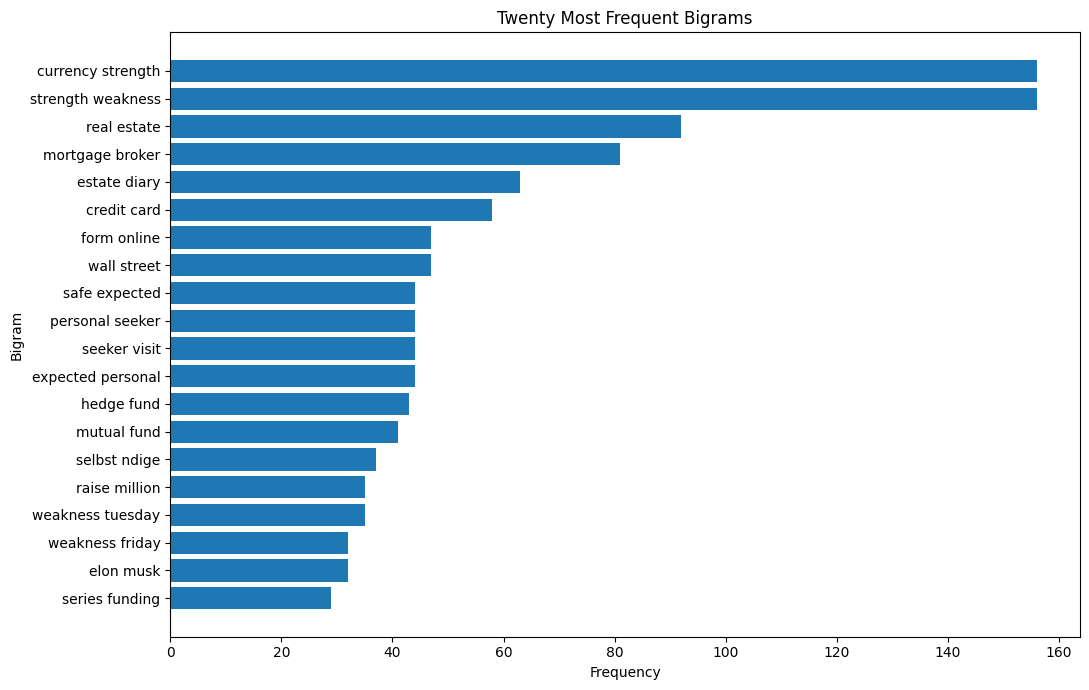

In [785]:
# Visualise common two-word expressions

plt.figure(figsize=(11, 7))

plt.barh(
    top_bigrams["Bigram"][::-1],
    top_bigrams["Frequency"][::-1]
)

plt.title("Twenty Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

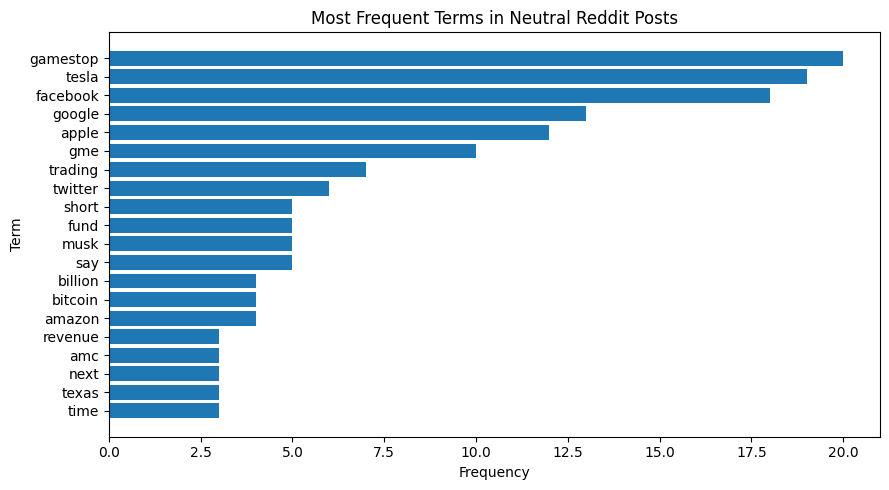

In [786]:
# Ensure the sentiment_class is defined before filtering

# Map classes if the column is missing
if "sentiment_class" not in stock_posts.columns:
    stock_posts["sentiment_class"] = stock_posts["compound_sentiment"].apply(classify_sentiment)

# Now perform the filtering for Neutral posts
neutral_posts_text = stock_posts[
    stock_posts["sentiment_class"] == "Neutral"
]["refined_clean_text"].dropna()

all_neutral_tokens = []
for text in neutral_posts_text:
    all_neutral_tokens.extend(text.split())

neutral_word_frequency = Counter(all_neutral_tokens)
neutral_terms = pd.DataFrame(
    neutral_word_frequency.most_common(20),
    columns=["Term", "Frequency"]
)

plt.figure(figsize=(9, 5))
plt.barh(neutral_terms["Term"][::-1], neutral_terms["Frequency"][::-1])
plt.title("Most Frequent Terms in Neutral Reddit Posts")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

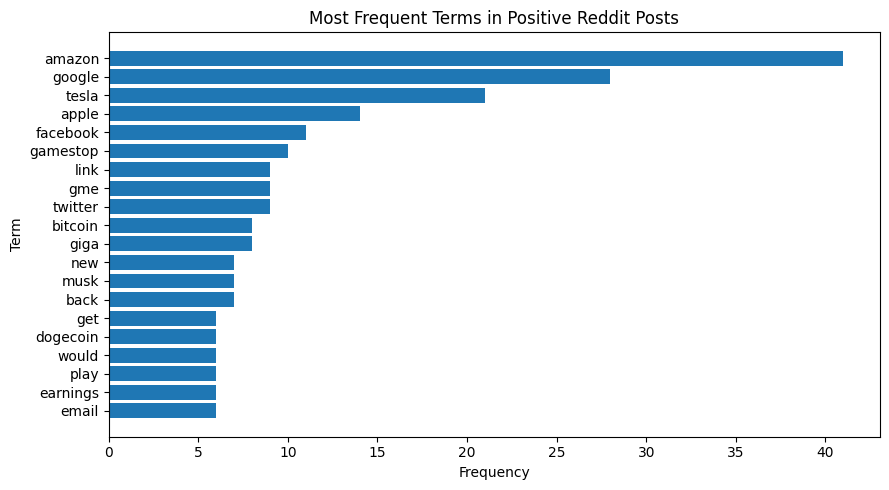

In [787]:
analysis_df["refined_clean_text"] = (
    analysis_df["clean_text"]
    .apply(remove_domain_stop_words)
)

# Ensure refined_clean_text is available in stock_posts by mapping
stock_posts["refined_clean_text"] = stock_posts["id"].map(
    analysis_df.set_index("id")["refined_clean_text"]
)


stock_posts["sentiment_class"] = (
    stock_posts["compound_sentiment"]
    .apply(classify_sentiment)
)

positive_posts_text = stock_posts[
    stock_posts["sentiment_class"] == "Positive"
]["refined_clean_text"].dropna()

all_positive_tokens = []

for text in positive_posts_text:
    all_positive_tokens.extend(text.split())

positive_word_frequency = Counter(all_positive_tokens)

positive_terms = pd.DataFrame(
    positive_word_frequency.most_common(20),
    columns=[
        "Term",
        "Frequency"
    ]
)

plt.figure(figsize=(9, 5))

plt.barh(
    positive_terms["Term"][::-1],
    positive_terms["Frequency"][::-1]
)

plt.title("Most Frequent Terms in Positive Reddit Posts")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

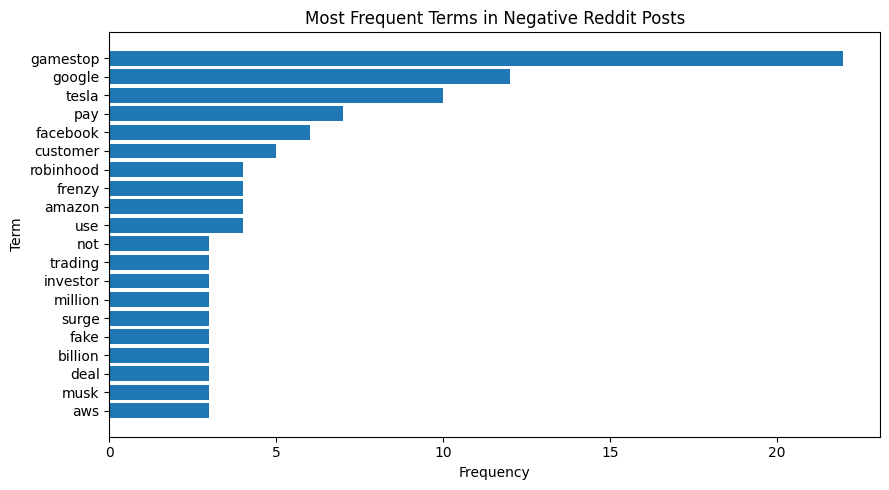

In [788]:
negative_posts_text = stock_posts[
    stock_posts["sentiment_class"]
    == "Negative"
]["refined_clean_text"].dropna()

negative_tokens = []

for text in negative_posts_text:
    negative_tokens.extend(
        text.split()
    )

negative_word_frequency = Counter(
    negative_tokens
)

negative_terms = pd.DataFrame(
    negative_word_frequency.most_common(20),
    columns=[
        "Term",
        "Frequency"
    ]
)

plt.figure(figsize=(9, 5))

plt.barh(
    negative_terms["Term"][::-1],
    negative_terms["Frequency"][::-1]
)

plt.title(
    "Most Frequent Terms in Negative Reddit Posts"
)

plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

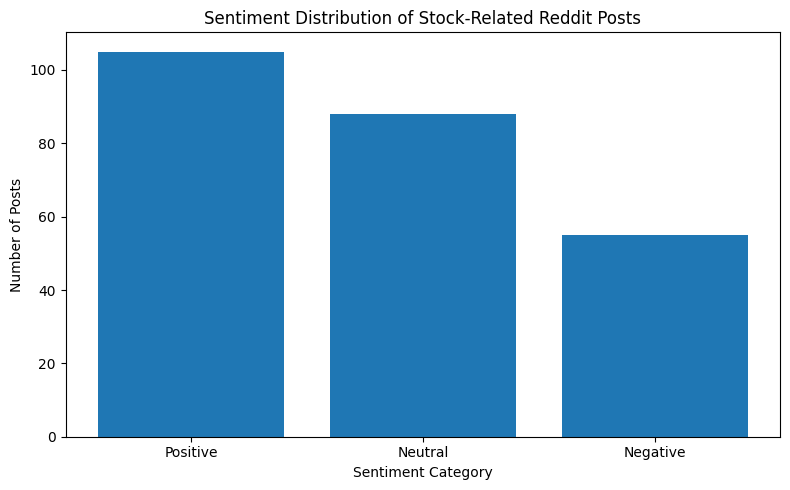

In [789]:
# Visualise the number of positive, neutral and negative stock-related posts

plt.figure(figsize=(8, 5))
plt.bar(
    sentiment_distribution.index,
    sentiment_distribution.values
)

plt.title("Sentiment Distribution of Stock-Related Reddit Posts")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

In [790]:
# Calculate stock-level sentiment statistics

stock_sentiment_summary = (
    stock_posts
    .groupby("ticker")
    .agg(
        Number_of_Posts=("id", "count"),
        Mean_Sentiment=("compound_sentiment", "mean"),
        Median_Sentiment=("compound_sentiment", "median"),
        Sentiment_Standard_Deviation=("compound_sentiment", "std"),
        Mean_Score=("score", "mean"),
        Mean_Comments=("num_comments", "mean")
    )
    .sort_values(
        by="Number_of_Posts",
        ascending=False
    )
)

stock_sentiment_summary.round(3)

,Number_of_Posts,Mean_Sentiment,Median_Sentiment,Sentiment_Standard_Deviation,Mean_Score,Mean_Comments
ticker,,,,,,
GME,67,-0.032,0.000,0.374,221.642,26.254
GOOGL,42,0.173,0.178,0.417,20.595,2.810
TSLA,42,0.110,0.000,0.419,95.833,21.286
AMZN,40,0.271,0.178,0.343,88.550,9.775
META,32,0.093,0.000,0.334,1.969,0.688
AAPL,25,0.192,0.000,0.270,37.320,3.440


In [791]:
# Create a separate dataframe for the sentiment-consistency experiment.
# Each post has:
# - cleaned textual input
# - a VADER-generated pseudo-label

sentiment_model_df = stock_posts[
    [
        "id",
        "ticker",
        "title",
        "raw_text",
        "clean_text",
        "sentiment_class"
    ]
].dropna(
    subset=[
        "clean_text",
        "sentiment_class"
    ]
).copy()

# Remove any remaining empty texts
sentiment_model_df = sentiment_model_df[
    sentiment_model_df[
        "clean_text"
    ].str.strip() != ""
].copy()

print(
    "Sentiment-classification observations:",
    len(sentiment_model_df)
)

print("\nClass distribution:")
print(
    sentiment_model_df[
        "sentiment_class"
    ].value_counts()
)

print("\nClass percentages:")
print(
    sentiment_model_df[
        "sentiment_class"
    ].value_counts(
        normalize=True
    ).mul(100).round(2)
)

Sentiment-classification observations: 248

Class distribution:
sentiment_class
Positive    105
Neutral      88
Negative     55
Name: count, dtype: int64

Class percentages:
sentiment_class
Positive    42.34
Neutral     35.48
Negative    22.18
Name: proportion, dtype: float64


In [792]:
# Convert Positive, Neutral and Negative labels into numeric values.
# The mapping is saved and displayed for reproducibility.

sentiment_label_encoder = LabelEncoder()

sentiment_model_df[
    "encoded_sentiment"
] = sentiment_label_encoder.fit_transform(
    sentiment_model_df[
        "sentiment_class"
    ]
)

sentiment_label_mapping = {
    class_name: int(encoded_value)
    for class_name, encoded_value
    in zip(
        sentiment_label_encoder.classes_,
        sentiment_label_encoder.transform(
            sentiment_label_encoder.classes_
        )
    )
}

print(
    "Sentiment label mapping:",
    sentiment_label_mapping
)

Sentiment label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


# **Data Split**

In [793]:
# A stratified split preserves approximately the same class distribution
# in the training and testing subsets.

X_text = sentiment_model_df[
    "clean_text"
]

y_sentiment = sentiment_model_df[
    "encoded_sentiment"
]

(
    X_text_train,
    X_text_test,
    y_sentiment_train,
    y_sentiment_test
) = train_test_split(
    X_text,
    y_sentiment,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sentiment
)

print(
    "Training observations:",
    len(X_text_train)
)

print(
    "Testing observations:",
    len(X_text_test)
)

print("\nTraining class distribution:")
print(
    y_sentiment_train.value_counts(
        normalize=True
    ).sort_index().round(3)
)

print("\nTesting class distribution:")
print(
    y_sentiment_test.value_counts(
        normalize=True
    ).sort_index().round(3)
)

Training observations: 198
Testing observations: 50

Training class distribution:
encoded_sentiment
0    0.222
1    0.354
2    0.424
Name: proportion, dtype: float64

Testing class distribution:
encoded_sentiment
0    0.22
1    0.36
2    0.42
Name: proportion, dtype: float64


In [794]:
# Convert cleaned text into numerical TF-IDF features.

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_tfidf_train = (
    tfidf_vectorizer.fit_transform(
        X_text_train
    )
)

X_tfidf_test = (
    tfidf_vectorizer.transform(
        X_text_test
    )
)

print(
    "Training TF-IDF shape:",
    X_tfidf_train.shape
)

print(
    "Testing TF-IDF shape:",
    X_tfidf_test.shape
)

print(
    "Vocabulary size:",
    len(
        tfidf_vectorizer
        .get_feature_names_out()
    )
)

Training TF-IDF shape: (198, 353)
Testing TF-IDF shape: (50, 353)
Vocabulary size: 353


# **Model Implementation**

In [795]:
# Multinomial Naïve Bayes is a computationally efficient
# benchmark for sparse TF-IDF text features.

def evaluate_sentiment_classifier(
    model_name,
    model,
    training_features,
    training_labels,
    testing_features,
    testing_labels
):
    """
    Train a sentiment classification model and evaluate its performance.
    """

    start_time = time.time()

    model.fit(
        training_features,
        training_labels
    )

    predictions = model.predict(
        testing_features
    )

    end_time = time.time()
    training_time = end_time - start_time

    accuracy = accuracy_score(
        testing_labels,
        predictions
    )

    precision = precision_score(
        testing_labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        testing_labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        testing_labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "Training_Time": training_time
    }, predictions, model


naive_bayes_model = MultinomialNB(
    alpha=1.0
)

(
    naive_bayes_result,
    naive_bayes_predictions,
    naive_bayes_model
) = evaluate_sentiment_classifier(
    model_name="Multinomial Naive Bayes",
    model=naive_bayes_model,
    training_features=X_tfidf_train,
    training_labels=y_sentiment_train,
    testing_features=X_tfidf_test,
    testing_labels=y_sentiment_test
)

pd.DataFrame(
    [naive_bayes_result]
).round(4)

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time
0,Multinomial Naive Bayes,0.58,0.6621,0.58,0.548,0.0024


In [796]:
# Logistic Regression provides a linear and interpretable
# multiclass text-classification benchmark.

sentiment_logistic_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

(
    logistic_sentiment_result,
    logistic_sentiment_predictions,
    sentiment_logistic_model
) = evaluate_sentiment_classifier(
    model_name="Logistic Regression",
    model=sentiment_logistic_model,
    training_features=X_tfidf_train,
    training_labels=y_sentiment_train,
    testing_features=X_tfidf_test,
    testing_labels=y_sentiment_test
)

pd.DataFrame(
    [
        naive_bayes_result,
        logistic_sentiment_result
    ]
).round(4)

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time
0,Multinomial Naive Bayes,0.58,0.6621,0.58,0.5480,0.0024
1,Logistic Regression,0.58,0.5763,0.58,0.5664,0.0083


In [797]:
# Linear SVM is frequently effective for high-dimensional,
# sparse text-classification tasks.

linear_svm_model = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

(
    linear_svm_result,
    linear_svm_predictions,
    linear_svm_model
) = evaluate_sentiment_classifier(
    model_name="Linear SVM",
    model=linear_svm_model,
    training_features=X_tfidf_train,
    training_labels=y_sentiment_train,
    testing_features=X_tfidf_test,
    testing_labels=y_sentiment_test
)

pd.DataFrame(
    [
        naive_bayes_result,
        logistic_sentiment_result,
        linear_svm_result
    ]
).round(4)

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time
0,Multinomial Naive Bayes,0.58,0.6621,0.58,0.5480,0.0024
1,Logistic Regression,0.58,0.5763,0.58,0.5664,0.0083
2,Linear SVM,0.64,0.6383,0.64,0.6306,0.0045


In [798]:
xgboost_sentiment_model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.80,
    colsample_bytree=0.80,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

(
    xgboost_sentiment_result,
    xgboost_sentiment_predictions,
    xgboost_sentiment_model
) = evaluate_sentiment_classifier(
    model_name="XGBoost Classifier",
    model=xgboost_sentiment_model,
    training_features=X_tfidf_train,
    training_labels=y_sentiment_train,
    testing_features=X_tfidf_test,
    testing_labels=y_sentiment_test
)

sentiment_classification_results = pd.DataFrame([
    naive_bayes_result,
    logistic_sentiment_result,
    linear_svm_result,
    xgboost_sentiment_result
]).sort_values(
    by="F1_Score",
    ascending=False
)

sentiment_classification_results.round(4)

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time
3,XGBoost Classifier,0.72,0.7226,0.72,0.7122,0.2199
2,Linear SVM,0.64,0.6383,0.64,0.6306,0.0045
1,Logistic Regression,0.58,0.5763,0.58,0.5664,0.0083
0,Multinomial Naive Bayes,0.58,0.6621,0.58,0.5480,0.0024


In [799]:
# Validate sentiment models using stratified cross-validation

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

sentiment_models_for_cv = {
    "Multinomial Naive Bayes":
        MultinomialNB(alpha=1.0),

    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    "Linear SVM":
        LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
}

sentiment_cv_results = []

for model_name, model in sentiment_models_for_cv.items():

    cv_scores = cross_validate(
        estimator=model,
        X=X_tfidf_train,
        y=y_sentiment_train,
        cv=stratified_cv,
        scoring={
            "accuracy": "accuracy",
            "weighted_f1": "f1_weighted"
        },
        n_jobs=-1,
        return_train_score=False
    )

    sentiment_cv_results.append({
        "Model": model_name,

        "Mean_CV_Accuracy":
            cv_scores["test_accuracy"].mean(),

        "SD_CV_Accuracy":
            cv_scores["test_accuracy"].std(),

        "Mean_CV_F1":
            cv_scores["test_weighted_f1"].mean(),

        "SD_CV_F1":
            cv_scores["test_weighted_f1"].std()
    })

sentiment_cv_comparison = (
    pd.DataFrame(sentiment_cv_results)
    .sort_values(
        by="Mean_CV_F1",
        ascending=False
    )
)

sentiment_cv_comparison.round(4)

,Model,Mean_CV_Accuracy,SD_CV_Accuracy,Mean_CV_F1,SD_CV_F1
2,Linear SVM,0.5103,0.0650,0.5014,0.0679
1,Logistic Regression,0.4858,0.1222,0.4823,0.1206
0,Multinomial Naive Bayes,0.5205,0.0743,0.4818,0.0760


In [800]:
# Tune the regularisation strength of the linear text models

logistic_parameter_grid = {
    "C": [
        0.01,
        0.1,
        1,
        10
    ]
}

logistic_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    param_grid=logistic_parameter_grid,
    scoring="f1_weighted",
    cv=stratified_cv,
    n_jobs=-1
)

logistic_search.fit(
    X_tfidf_train,
    y_sentiment_train
)

svm_parameter_grid = {
    "C": [
        0.01,
        0.1,
        1,
        10
    ]
}

svm_search = GridSearchCV(
    estimator=LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    param_grid=svm_parameter_grid,
    scoring="f1_weighted",
    cv=stratified_cv,
    n_jobs=-1
)

svm_search.fit(
    X_tfidf_train,
    y_sentiment_train
)

print(
    "Best Logistic Regression parameters:",
    logistic_search.best_params_
)

print(
    "Best Logistic Regression CV F1:",
    round(logistic_search.best_score_, 4)
)

print(
    "Best Linear SVM parameters:",
    svm_search.best_params_
)

print(
    "Best Linear SVM CV F1:",
    round(svm_search.best_score_, 4)
)

Best Logistic Regression parameters: {'C': 10}
Best Logistic Regression CV F1: 0.5174
Best Linear SVM parameters: {'C': 0.1}
Best Linear SVM CV F1: 0.5125


# **Model Evaluation**

In [801]:
# Evaluate tuned Logistic Regression

tuned_logistic_result = {
    "Model": "Tuned Logistic Regression",

    "Accuracy": accuracy_score(
        y_sentiment_test,
        tuned_logistic_predictions
    ),

    "Precision": precision_score(
        y_sentiment_test,
        tuned_logistic_predictions,
        average="weighted",
        zero_division=0
    ),

    "Recall": recall_score(
        y_sentiment_test,
        tuned_logistic_predictions,
        average="weighted",
        zero_division=0
    ),

    "F1_Score": f1_score(
        y_sentiment_test,
        tuned_logistic_predictions,
        average="weighted",
        zero_division=0
    ),

    "Training_Time": np.nan
}


# Evaluate tuned Linear SVM

tuned_svm_result = {
    "Model": "Tuned Linear SVM",

    "Accuracy": accuracy_score(
        y_sentiment_test,
        tuned_svm_predictions
    ),

    "Precision": precision_score(
        y_sentiment_test,
        tuned_svm_predictions,
        average="weighted",
        zero_division=0
    ),

    "Recall": recall_score(
        y_sentiment_test,
        tuned_svm_predictions,
        average="weighted",
        zero_division=0
    ),

    "F1_Score": f1_score(
        y_sentiment_test,
        tuned_svm_predictions,
        average="weighted",
        zero_division=0
    ),

    "Training_Time": np.nan
}


sentiment_classification_results = pd.concat(
    [
        sentiment_classification_results,

        pd.DataFrame([
            tuned_logistic_result,
            tuned_svm_result
        ])
    ],
    ignore_index=True
).sort_values(
    by="F1_Score",
    ascending=False
)

sentiment_classification_results.round(4)

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time
0,XGBoost Classifier,0.72,0.7226,0.72,0.7122,0.2199
1,Linear SVM,0.64,0.6383,0.64,0.6306,0.0045
5,Tuned Linear SVM,0.60,0.6297,0.60,0.5831,NaN
4,Tuned Logistic Regression,0.58,0.5800,0.58,0.5759,NaN
2,Logistic Regression,0.58,0.5763,0.58,0.5664,0.0083
3,Multinomial Naive Bayes,0.58,0.6621,0.58,0.5480,0.0024


In [802]:
xgboost_params = {
    "XGBoost Classifier": XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        min_child_weight=3,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=1.50,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

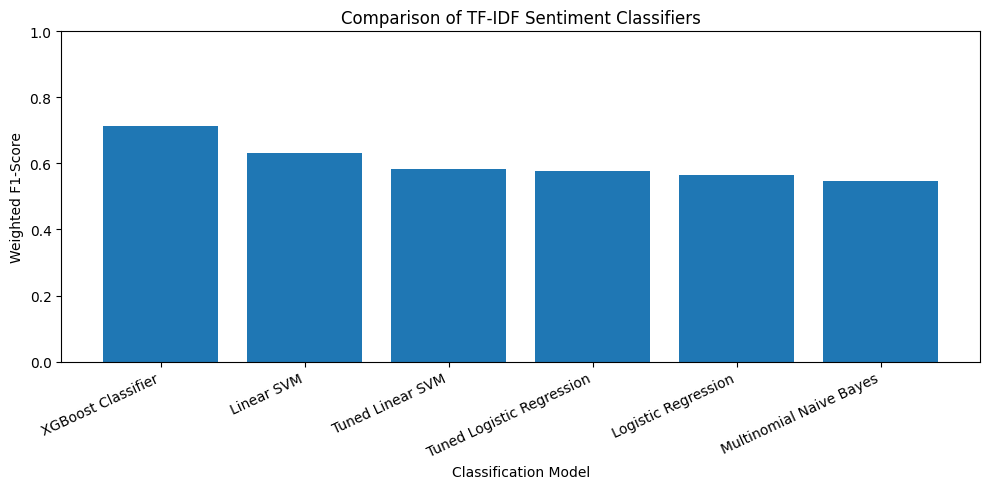

In [803]:
plt.figure(figsize=(10, 5))

plt.bar(
    sentiment_classification_results["Model"],
    sentiment_classification_results["F1_Score"]
)

plt.title("Comparison of TF-IDF Sentiment Classifiers")
plt.xlabel("Classification Model")
plt.ylabel("Weighted F1-Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

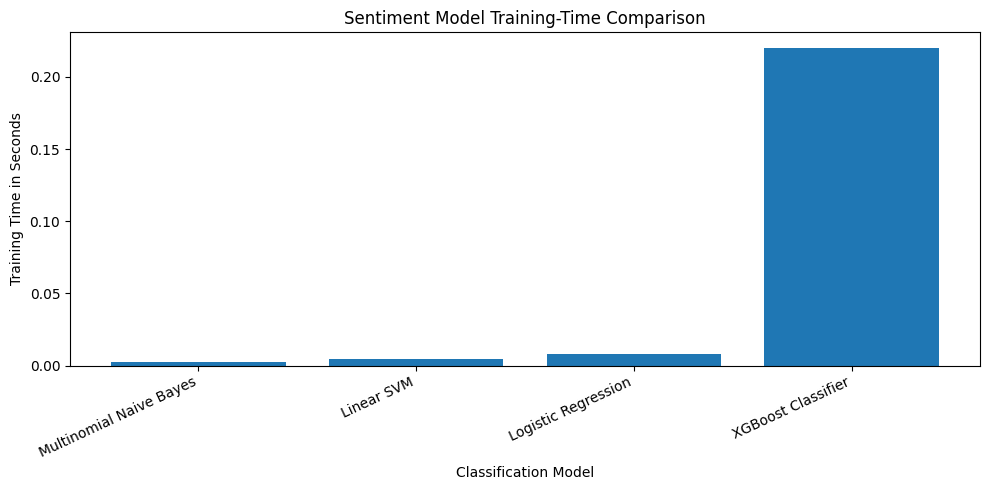

In [804]:
training_time_results = (
    sentiment_classification_results
    .sort_values(
        by="Training_Time"
    )
)

plt.figure(figsize=(10, 5))

plt.bar(
    training_time_results["Model"],
    training_time_results[
        "Training_Time"
    ]
)

plt.title("Sentiment Model Training-Time Comparison")
plt.xlabel("Classification Model")
plt.ylabel("Training Time in Seconds")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [805]:
sentiment_model_predictions = {
    "Multinomial Naive Bayes":
        naive_bayes_predictions,

    "Logistic Regression":
        logistic_sentiment_predictions,

    "Linear SVM":
        linear_svm_predictions,

    "XGBoost Classifier":
        xgboost_sentiment_predictions
}

class_names = (
    sentiment_label_encoder.classes_
)

for model_name, predictions in (
    sentiment_model_predictions.items()
):

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_sentiment_test,
            predictions,
            target_names=class_names,
            zero_division=0
        )
    )


Multinomial Naive Bayes
              precision    recall  f1-score   support

    Negative       1.00      0.18      0.31        11
     Neutral       0.59      0.56      0.57        18
    Positive       0.55      0.81      0.65        21

    accuracy                           0.58        50
   macro avg       0.71      0.52      0.51        50
weighted avg       0.66      0.58      0.55        50


Logistic Regression
              precision    recall  f1-score   support

    Negative       0.50      0.27      0.35        11
     Neutral       0.65      0.61      0.63        18
    Positive       0.56      0.71      0.62        21

    accuracy                           0.58        50
   macro avg       0.57      0.53      0.54        50
weighted avg       0.58      0.58      0.57        50


Linear SVM
              precision    recall  f1-score   support

    Negative       0.57      0.36      0.44        11
     Neutral       0.71      0.67      0.69        18
    Positive     

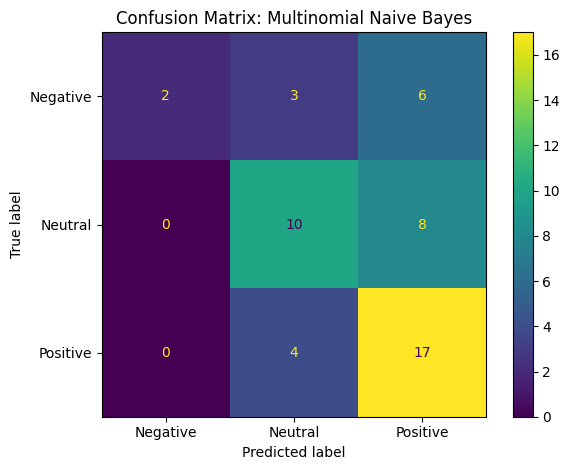

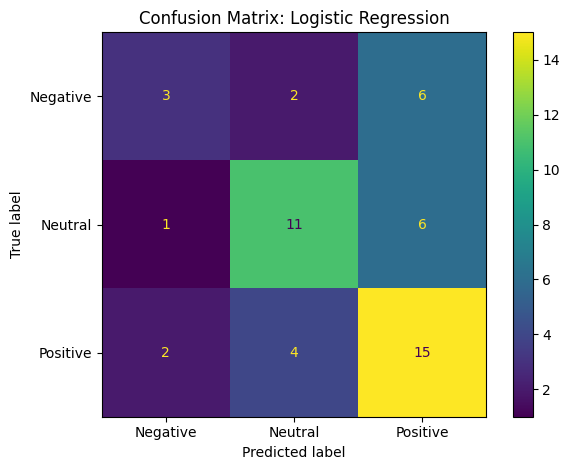

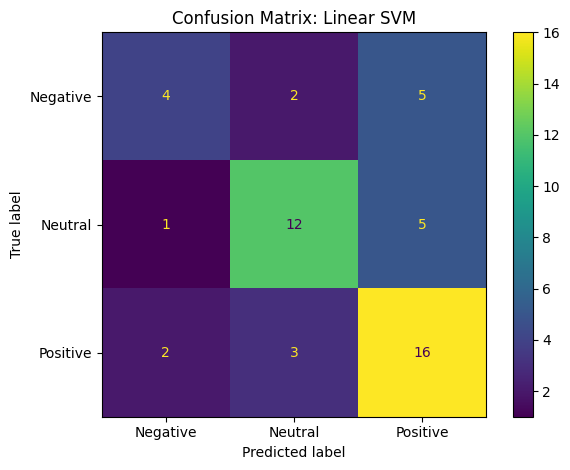

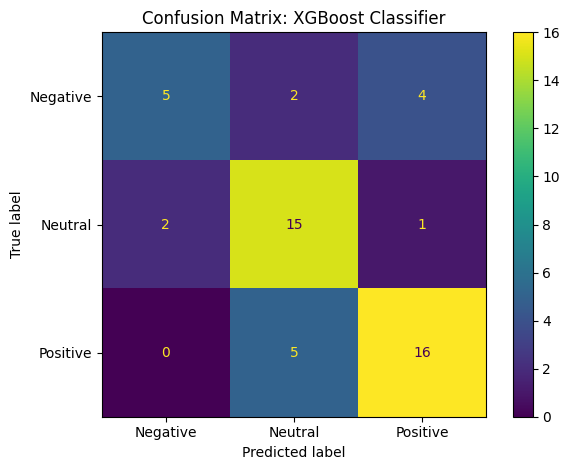

In [806]:
# Display one confusion matrix for each classifier

for model_name, predictions in (
    sentiment_model_predictions.items()
):

    matrix_display = (
        ConfusionMatrixDisplay
        .from_predictions(
            y_sentiment_test,
            predictions,
            display_labels=class_names,
            values_format="d"
        )
    )

    matrix_display.ax_.set_title(
        f"Confusion Matrix: {model_name}"
    )

    plt.tight_layout()
    plt.show()

In [807]:
prediction_lookup = {
    "Multinomial Naive Bayes":
        naive_bayes_predictions,

    "Logistic Regression":
        logistic_sentiment_predictions,

    "Linear SVM":
        linear_svm_predictions,

    "XGBoost Classifier":
        xgboost_sentiment_predictions
}

best_sentiment_model_name = (
    sentiment_classification_results["Model"].iloc[0]
)

best_sentiment_predictions = (
    prediction_lookup[
        best_sentiment_model_name
    ]
)

print(
    "Error analysis will use:",
    best_sentiment_model_name
)

Error analysis will use: XGBoost Classifier


In [808]:
# Recover the original test records using their retained indices.

sentiment_error_analysis = (
    sentiment_model_df.loc[
        X_text_test.index,
        [
            "title",
            "raw_text",
            "clean_text",
            "sentiment_class"
        ]
    ].copy()
)

sentiment_error_analysis[
    "Predicted_Encoded_Label"
] = best_sentiment_predictions

sentiment_error_analysis[
    "Predicted_Sentiment"
] = sentiment_label_encoder.inverse_transform(
    best_sentiment_predictions
)

sentiment_error_analysis[
    "Correct_Prediction"
] = (
    sentiment_error_analysis[
        "sentiment_class"
    ]
    ==
    sentiment_error_analysis[
        "Predicted_Sentiment"
    ]
)

misclassified_posts = sentiment_error_analysis[
    sentiment_error_analysis[
        "Correct_Prediction"
    ] == False
].copy()

print(
    "Number of misclassified posts:",
    len(misclassified_posts)
)

print(
    "Misclassification rate:",
    round(
        len(misclassified_posts)
        / len(sentiment_error_analysis)
        * 100,
        2
    ),
    "%"
)

misclassified_posts[
    [
        "title",
        "sentiment_class",
        "Predicted_Sentiment"
    ]
].head(25)

Number of misclassified posts: 14
Misclassification rate: 28.0 %


,title,sentiment_class,Predicted_Sentiment
35,How Reddit challenged Wall Street (GameStop ex...,Negative,Positive
113,Amazon accused of abuse of dominant position i...,Negative,Positive
36,Farage: GameStop Rebellion the Populist Succes...,Positive,Neutral
10,Brrr Tesla!!!! Shhh,Neutral,Negative
216,Traders Bet Tesla Stock’s Rally Isn’t Over Jus...,Neutral,Negative
207,Dukat Currency now on Google Play,Positive,Neutral
224,"How a 2,360% Jump in Call Options Fired Up Tes...",Negative,Positive
28,To my U.K. bros. I’ve created a petition to th...,Positive,Neutral
40,"Melvin Capital Lost 53% in January, Hurt by Ga...",Negative,Neutral
185,"Google, Gmail, and Youtube will no longer work...",Negative,Neutral


In [809]:
# Count each actual-to-predicted error combination.

error_pattern_table = (
    misclassified_posts
    .groupby(
        [
            "sentiment_class",
            "Predicted_Sentiment"
        ]
    )
    .size()
    .reset_index(
        name="Error_Count"
    )
    .sort_values(
        by="Error_Count",
        ascending=False
    )
)

error_pattern_table

,sentiment_class,Predicted_Sentiment,Error_Count
4,Positive,Neutral,5
1,Negative,Positive,4
0,Negative,Neutral,2
2,Neutral,Negative,2
3,Neutral,Positive,1


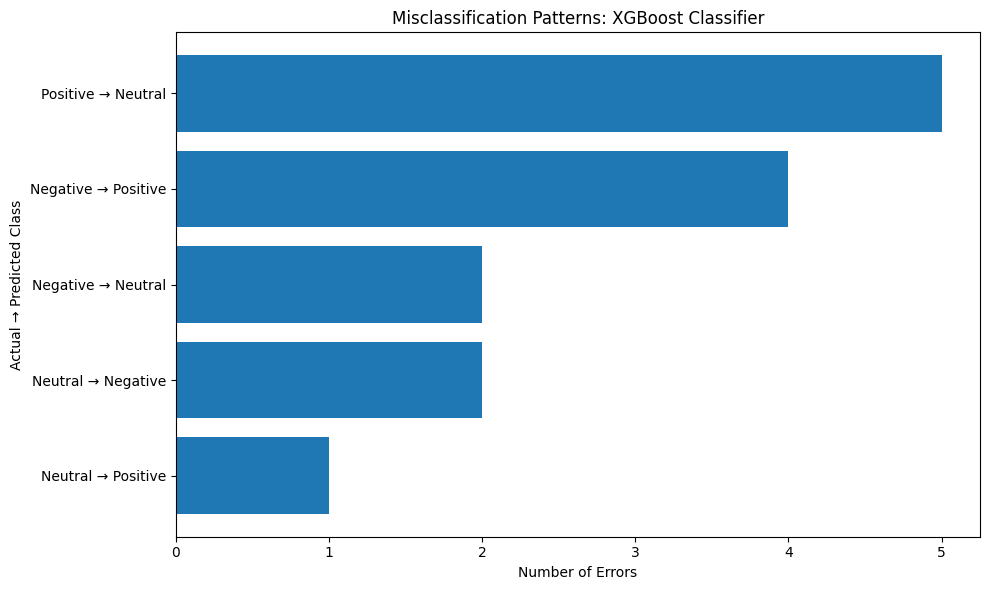

In [810]:
# Create readable labels for each error direction.

error_pattern_table[
    "Error_Type"
] = (
    error_pattern_table[
        "sentiment_class"
    ]
    + " → "
    + error_pattern_table[
        "Predicted_Sentiment"
    ]
)

plt.figure(figsize=(10, 6))

plt.barh(
    error_pattern_table[
        "Error_Type"
    ][::-1],
    error_pattern_table[
        "Error_Count"
    ][::-1]
)

plt.title(
    f"Misclassification Patterns: {best_sentiment_model_name}"
)

plt.xlabel("Number of Errors")
plt.ylabel("Actual → Predicted Class")
plt.tight_layout()
plt.show()

In [811]:
if not error_pattern_table.empty:

    most_common_error = (
        error_pattern_table.iloc[0]
    )

    print(
        "Most frequent error type:",
        most_common_error[
            "sentiment_class"
        ],
        "predicted as",
        most_common_error[
            "Predicted_Sentiment"
        ]
    )

    print(
        "Number of occurrences:",
        int(
            most_common_error[
                "Error_Count"
            ]
        )
    )

else:
    print(
        "No misclassifications were identified."
    )

Most frequent error type: Positive predicted as Neutral
Number of occurrences: 5


In [812]:
# Display examples from each major error category.

for _, error_row in (
    error_pattern_table
    .head(5)
    .iterrows()
):

    actual_class = (
        error_row["sentiment_class"]
    )

    predicted_class = (
        error_row["Predicted_Sentiment"]
    )

    examples = misclassified_posts[
        (
            misclassified_posts[
                "sentiment_class"
            ] == actual_class
        )
        &
        (
            misclassified_posts[
                "Predicted_Sentiment"
            ] == predicted_class
        )
    ][
        [
            "title",
            "sentiment_class",
            "Predicted_Sentiment"
        ]
    ].head(5)

    print("\n" + "-" * 70)

    print(
        f"Actual {actual_class} "
        f"predicted as {predicted_class}"
    )

    display(examples)


----------------------------------------------------------------------
Actual Positive predicted as Neutral


,title,sentiment_class,Predicted_Sentiment
36,Farage: GameStop Rebellion the Populist Succes...,Positive,Neutral
207,Dukat Currency now on Google Play,Positive,Neutral
28,To my U.K. bros. I’ve created a petition to th...,Positive,Neutral
164,We created a website that provides all fundame...,Positive,Neutral
88,Splitit: Now Available on the Google Store in ...,Positive,Neutral



----------------------------------------------------------------------
Actual Negative predicted as Positive


,title,sentiment_class,Predicted_Sentiment
35,How Reddit challenged Wall Street (GameStop ex...,Negative,Positive
113,Amazon accused of abuse of dominant position i...,Negative,Positive
224,"How a 2,360% Jump in Call Options Fired Up Tes...",Negative,Positive
68,Microsoft’s $10 billion Pentagon deal at risk ...,Negative,Positive



----------------------------------------------------------------------
Actual Negative predicted as Neutral


,title,sentiment_class,Predicted_Sentiment
40,"Melvin Capital Lost 53% in January, Hurt by Ga...",Negative,Neutral
185,"Google, Gmail, and Youtube will no longer work...",Negative,Neutral



----------------------------------------------------------------------
Actual Neutral predicted as Negative


,title,sentiment_class,Predicted_Sentiment
10,Brrr Tesla!!!! Shhh,Neutral,Negative
216,Traders Bet Tesla Stock’s Rally Isn’t Over Jus...,Neutral,Negative



----------------------------------------------------------------------
Actual Neutral predicted as Positive


,title,sentiment_class,Predicted_Sentiment
144,YVR Stock Increases Over 35% Intraday: Details...,Neutral,Positive


In [813]:
# Extract terms that most strongly influence each class

feature_names = (
    tfidf_vectorizer
    .get_feature_names_out()
)

logistic_coefficients = (
    sentiment_logistic_model
    .named_steps["model"].coef_
    if isinstance(
        sentiment_logistic_model,
        Pipeline
    )
    else sentiment_logistic_model.coef_
)

for class_index, class_name in enumerate(
    class_names
):

    strongest_indices = np.argsort(
        logistic_coefficients[
            class_index
        ]
    )[-15:]

    influential_terms = pd.DataFrame({
        "Term": feature_names[
            strongest_indices
        ],
        "Coefficient": logistic_coefficients[
            class_index,
            strongest_indices
        ]
    }).sort_values(
        by="Coefficient",
        ascending=False
    )

    print(
        f"\nMost influential terms for {class_name}:"
    )

    display(influential_terms)


Most influential terms for Negative:


,Term,Coefficient
14,pay,0.980369
13,right,0.955977
12,financial,0.773866
11,commission,0.769304
10,not,0.737675
9,drop,0.734433
8,soon,0.713657
7,phone,0.695997
6,deal,0.695318
5,employee,0.671967



Most influential terms for Neutral:


,Term,Coefficient
14,apple,0.691721
13,gamestop,0.640622
12,may,0.548718
11,texas,0.544055
10,became,0.537491
9,take,0.536437
8,year,0.493170
7,fund,0.485529
6,set,0.483470
5,changed,0.477155



Most influential terms for Positive:


,Term,Coefficient
14,amazon,1.625255
13,share,0.808784
12,new,0.580776
11,strong,0.547016
10,link,0.494313
9,bitcoin,0.459247
8,worth,0.455087
7,top,0.441546
6,reddit,0.434006
5,play,0.433725


In [814]:
# Create a moderated engagement weight
stock_posts["engagement_weight"] = (
    1
    + np.log1p(stock_posts["score_nonnegative"])
    + np.log1p(stock_posts["comments_nonnegative"])
)

# Multiply sentiment by engagement
stock_posts["weighted_sentiment_component"] = (
    stock_posts["compound_sentiment"]
    * stock_posts["engagement_weight"]
)

stock_posts[
    [
        "ticker",
        "compound_sentiment",
        "engagement_weight",
        "weighted_sentiment_component"
    ]
].head()

,ticker,compound_sentiment,engagement_weight,weighted_sentiment_component
0,TSLA,0.0000,2.098612,0.000000
1,TSLA,0.2960,1.693147,0.501172
2,AMZN,0.4939,12.495118,6.171339
3,AAPL,0.0000,1.693147,0.000000
4,AMZN,0.1779,1.693147,0.301211


In [815]:
def weighted_daily_sentiment(group):
    """
    Calculate engagement-weighted sentiment for a stock-date group.
    """

    weights = group["engagement_weight"]

    if weights.sum() == 0:
        return group["compound_sentiment"].mean()

    return np.average(
        group["compound_sentiment"],
        weights=weights
    )


# Standard daily summary
daily_base = (
    stock_posts
    .groupby(["date", "ticker"])
    .agg(
        average_sentiment=(
            "compound_sentiment",
            "mean"
        ),
        median_sentiment=(
            "compound_sentiment",
            "median"
        ),
        sentiment_volatility=(
            "compound_sentiment",
            "std"
        ),
        post_volume=(
            "id",
            "count"
        ),
        average_score=(
            "score",
            "mean"
        ),
        total_comments=(
            "num_comments",
            "sum"
        ),
        positive_share=(
            "sentiment_class",
            lambda x: (x == "Positive").mean()
        ),
        negative_share=(
            "sentiment_class",
            lambda x: (x == "Negative").mean()
        ),
        neutral_share=(
            "sentiment_class",
            lambda x: (x == "Neutral").mean()
        )
    )
    .reset_index()
)

# Engagement-weighted daily sentiment
weighted_daily = (
    stock_posts
    .groupby(["date", "ticker"])
    .apply(weighted_daily_sentiment)
    .reset_index(
        name="weighted_sentiment"
    )
)

daily_sentiment = daily_base.merge(
    weighted_daily,
    on=["date", "ticker"],
    how="left"
)

# A one-post day has no measurable within-day standard deviation
daily_sentiment["sentiment_volatility"] = (
    daily_sentiment["sentiment_volatility"]
    .fillna(0)
)

daily_sentiment.head()

,date,ticker,average_sentiment,median_sentiment,sentiment_volatility,post_volume,average_score,total_comments,positive_share,negative_share,neutral_share,weighted_sentiment
0,2021-01-02,TSLA,0.0000,0.0000,0.0,1,2.0,0,0.0,0.0,1.0,0.0000
1,2021-01-04,TSLA,0.2960,0.2960,0.0,1,1.0,0,1.0,0.0,0.0,0.2960
2,2021-01-05,AMZN,0.4939,0.4939,0.0,1,884.0,110,1.0,0.0,0.0,0.4939
3,2021-01-07,AAPL,0.0000,0.0000,0.0,1,1.0,0,0.0,0.0,1.0,0.0000
4,2021-01-11,AMZN,0.1779,0.1779,0.0,1,1.0,0,1.0,0.0,0.0,0.1779


In [816]:
# Determine how many stock-days are available for each company

coverage_summary = (
    daily_sentiment
    .groupby("ticker")
    .agg(
        Available_Days=("date", "nunique"),
        Total_Posts=("post_volume", "sum"),
        Mean_Daily_Posts=("post_volume", "mean"),
        First_Date=("date", "min"),
        Last_Date=("date", "max")
    )
    .sort_values(
        by="Available_Days",
        ascending=False
    )
)

coverage_summary

,Available_Days,Total_Posts,Mean_Daily_Posts,First_Date,Last_Date
ticker,,,,,
AMZN,37,40,1.081081,2021-01-05,2021-12-28
GOOGL,35,42,1.200000,2021-01-12,2021-12-30
TSLA,34,42,1.235294,2021-01-02,2021-11-25
GME,34,67,1.970588,2021-01-27,2021-12-06
META,28,32,1.142857,2021-02-08,2021-12-28
AAPL,24,25,1.041667,2021-01-07,2021-12-10


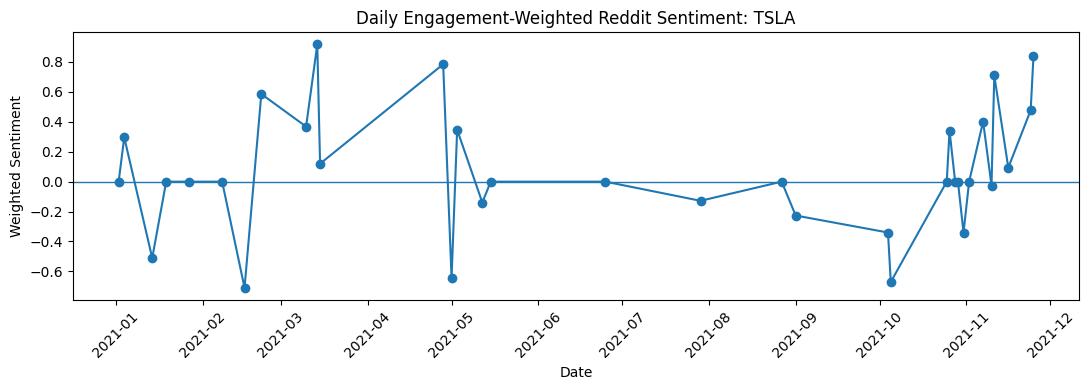

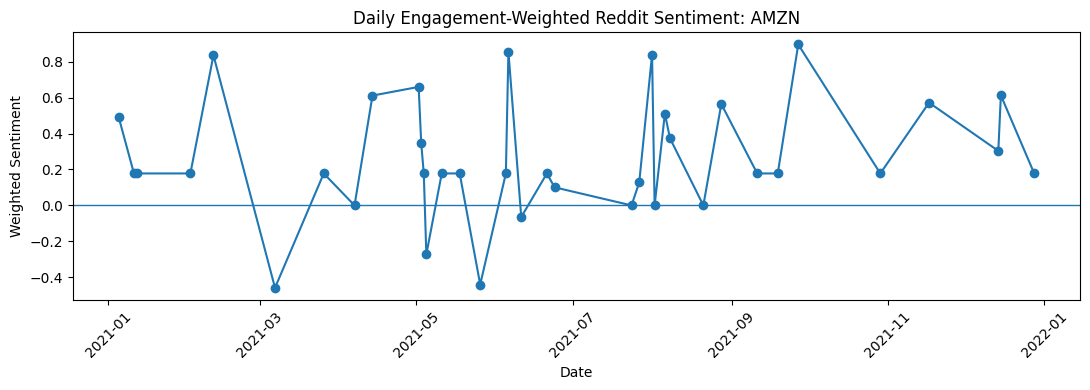

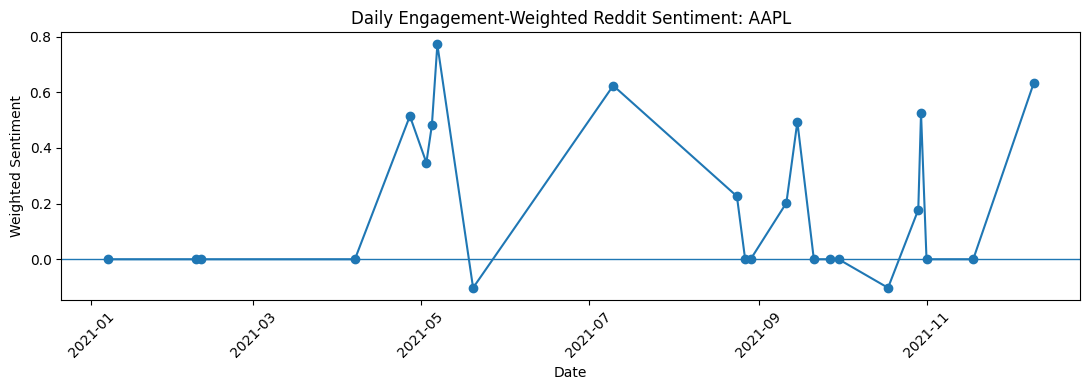

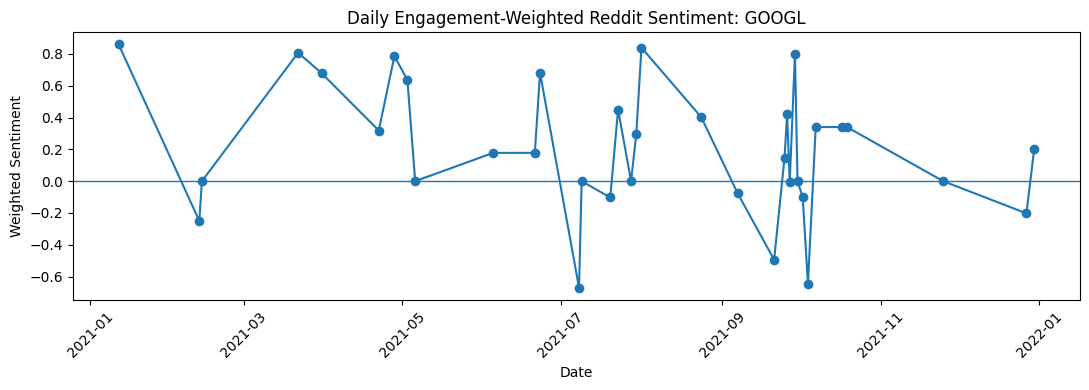

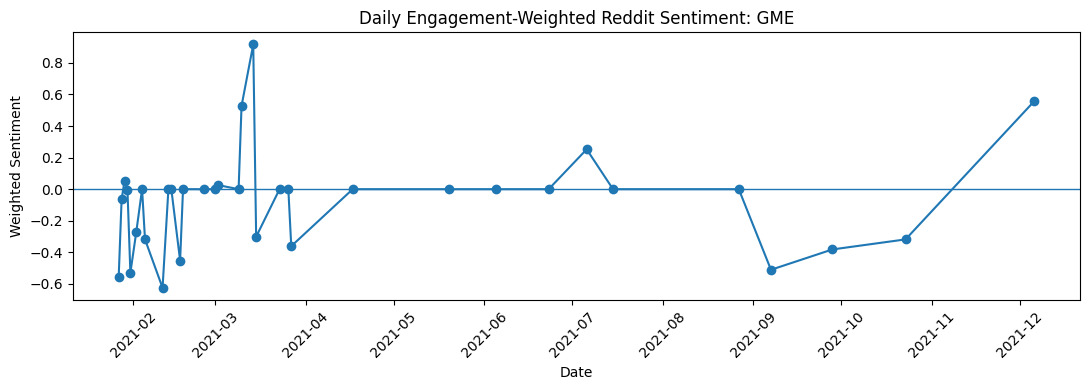

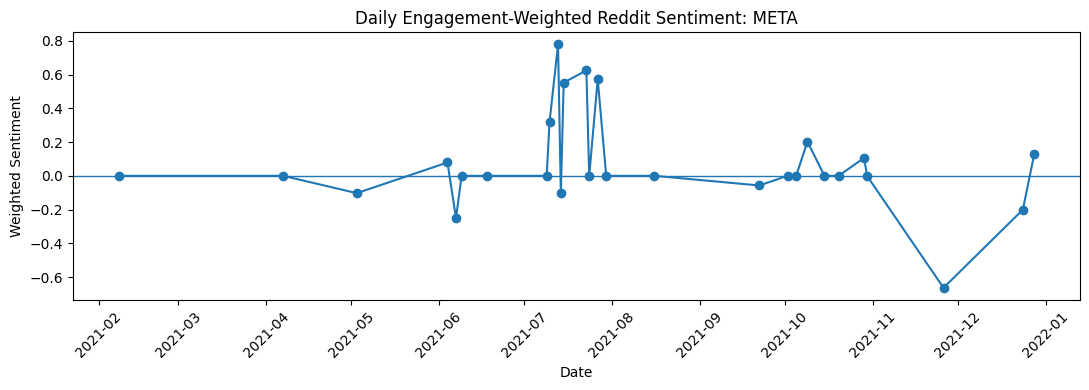

In [817]:
# Plot daily weighted sentiment separately for each stock

for ticker in daily_sentiment["ticker"].unique():

    ticker_data = daily_sentiment[
        daily_sentiment["ticker"] == ticker
    ].sort_values("date")

    plt.figure(figsize=(11, 4))

    plt.plot(
        ticker_data["date"],
        ticker_data["weighted_sentiment"],
        marker="o"
    )

    plt.axhline(
        y=0,
        linewidth=1
    )

    plt.title(
        f"Daily Engagement-Weighted Reddit Sentiment: {ticker}"
    )
    plt.xlabel("Date")
    plt.ylabel("Weighted Sentiment")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [818]:
# Define historical market-data period

price_start_date = "2020-12-20"
price_end_date = "2022-01-10"

selected_tickers = sorted(
    daily_sentiment["ticker"].unique()
)

print("Downloading prices for:", selected_tickers)

price_frames = []

for ticker in selected_tickers:

    ticker_prices = yf.download(
        ticker,
        start=price_start_date,
        end=price_end_date,
        progress=False,
        auto_adjust=False
    )

    if ticker_prices.empty:
        print(f"No market data returned for {ticker}")
        continue

    ticker_prices = ticker_prices.reset_index()

    # Handle possible MultiIndex columns produced by yfinance
    if isinstance(ticker_prices.columns, pd.MultiIndex):
        ticker_prices.columns = [
            column[0]
            if isinstance(column, tuple)
            else column
            for column in ticker_prices.columns
        ]

    ticker_prices["ticker"] = ticker

    price_frames.append(ticker_prices)

stock_prices = pd.concat(
    price_frames,
    ignore_index=True
)

print("Downloaded stock-price shape:", stock_prices.shape)

stock_prices.head()

Downloaded stock-price shape: (1590, 8)


,Date,Adj Close,Close,High,Low,Open,Volume,ticker
0,2020-12-21,124.594322,128.229996,128.309998,123.449997,125.019997,121251600,AAPL
1,2020-12-22,128.140854,131.880005,134.410004,129.649994,131.610001,168904800,AAPL
2,2020-12-23,127.246895,130.960007,132.429993,130.779999,132.160004,88223700,AAPL
3,2020-12-24,128.228256,131.970001,133.460007,131.100006,131.320007,54930100,AAPL
4,2020-12-28,132.814407,136.690002,137.339996,133.509995,133.990005,124486200,AAPL


In [819]:
# Standardise column names

stock_prices.columns = [
    str(column).lower().replace(" ", "_")
    for column in stock_prices.columns
]

# Convert the date column
stock_prices["date"] = pd.to_datetime(
    stock_prices["date"]
).dt.normalize()

# Sort chronologically within each stock
stock_prices = stock_prices.sort_values(
    ["ticker", "date"]
).reset_index(drop=True)

# Calculate same-day return
stock_prices["daily_return"] = (
    stock_prices
    .groupby("ticker")["close"]
    .pct_change()
)

# Create the next-trading-day return target
stock_prices["next_day_return"] = (
    stock_prices
    .groupby("ticker")["daily_return"]
    .shift(-1)
)

# Create the direction target:
# 1 = positive next-day return
# 0 = zero or negative next-day return
stock_prices["next_day_direction"] = (
    stock_prices["next_day_return"] > 0
).astype(int)

# Calculate historical price features
stock_prices["return_lag_1"] = (
    stock_prices
    .groupby("ticker")["daily_return"]
    .shift(1)
)

stock_prices["return_lag_2"] = (
    stock_prices
    .groupby("ticker")["daily_return"]
    .shift(2)
)

stock_prices["volatility_5d"] = (
    stock_prices
    .groupby("ticker")["daily_return"]
    .transform(
        lambda x: x.rolling(5).std()
    )
)

stock_prices[
    [
        "date",
        "ticker",
        "close",
        "daily_return",
        "next_day_return",
        "next_day_direction"
    ]
].head(10)

,date,ticker,close,daily_return,next_day_return,next_day_direction
0,2020-12-21,AAPL,128.229996,NaN,0.028465,1
1,2020-12-22,AAPL,131.880005,0.028465,-0.006976,0
2,2020-12-23,AAPL,130.960007,-0.006976,0.007712,1
3,2020-12-24,AAPL,131.970001,0.007712,0.035766,1
4,2020-12-28,AAPL,136.690002,0.035766,-0.013315,0
5,2020-12-29,AAPL,134.869995,-0.013315,-0.008527,0
6,2020-12-30,AAPL,133.720001,-0.008527,-0.007703,0
7,2020-12-31,AAPL,132.690002,-0.007703,-0.024719,0
8,2021-01-04,AAPL,129.410004,-0.024719,0.012364,1
9,2021-01-05,AAPL,131.009995,0.012364,-0.033662,0


In [820]:
# Create a stock-specific list of valid trading dates

trading_calendar = (
    stock_prices[
        ["ticker", "date"]
    ]
    .drop_duplicates()
    .sort_values(
        ["ticker", "date"]
    )
)

aligned_sentiment_frames = []

for ticker in selected_tickers:

    # Reddit observations for one stock
    sentiment_part = daily_sentiment[
        daily_sentiment["ticker"] == ticker
    ].sort_values("date").copy()

    # Trading dates for that stock
    trading_part = trading_calendar[
        trading_calendar["ticker"] == ticker
    ][["date"]].sort_values("date").copy()

    if sentiment_part.empty or trading_part.empty:
        continue

    # Rename Reddit date before alignment
    sentiment_part = sentiment_part.rename(
        columns={"date": "sentiment_date"}
    )

    # merge_asof with direction="forward" assigns each Reddit date
    # to the same or next available trading date
    aligned_part = pd.merge_asof(
        sentiment_part.sort_values("sentiment_date"),
        trading_part.rename(
            columns={"date": "trading_date"}
        ).sort_values("trading_date"),
        left_on="sentiment_date",
        right_on="trading_date",
        direction="forward"
    )

    aligned_sentiment_frames.append(aligned_part)

aligned_sentiment = pd.concat(
    aligned_sentiment_frames,
    ignore_index=True
)

aligned_sentiment[
    [
        "sentiment_date",
        "trading_date",
        "ticker",
        "weighted_sentiment"
    ]
].head()

,sentiment_date,trading_date,ticker,weighted_sentiment
0,2021-01-07,2021-01-07,AAPL,0.0000
1,2021-02-08,2021-02-08,AAPL,0.0000
2,2021-02-10,2021-02-10,AAPL,0.0000
3,2021-04-07,2021-04-07,AAPL,0.0000
4,2021-04-27,2021-04-27,AAPL,0.5147


In [821]:
model_df = daily_sentiment.merge(
    stock_prices,
    on=["date", "ticker"],
    how="left"
)

# Sort observations before creating time-dependent features
model_df = model_df.sort_values(
    ["ticker", "date"]
).reset_index(drop=True)

# Previous available sentiment observations
model_df["sentiment_lag_1"] = (
    model_df
    .groupby("ticker")["weighted_sentiment"]
    .shift(1)
)

model_df["sentiment_lag_2"] = (
    model_df
    .groupby("ticker")["weighted_sentiment"]
    .shift(2)
)

# Rolling sentiment averages use only earlier observations
model_df["sentiment_rolling_3"] = (
    model_df
    .groupby("ticker")["weighted_sentiment"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

model_df["sentiment_rolling_5"] = (
    model_df
    .groupby("ticker")["weighted_sentiment"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=5,
            min_periods=1
        ).mean()
    )
)

# Log-transform activity variables
model_df["log_post_volume"] = np.log1p(
    model_df["post_volume"]
)

model_df["log_total_comments"] = np.log1p(
    model_df["total_comments"]
)

model_df[
    [
        "date",
        "ticker",
        "weighted_sentiment",
        "sentiment_lag_1",
        "sentiment_rolling_3",
        "next_day_return"
    ]
].head(10)

,date,ticker,weighted_sentiment,sentiment_lag_1,sentiment_rolling_3,next_day_return
0,2021-01-07,AAPL,0.0000,NaN,NaN,0.008631
1,2021-02-08,AAPL,0.0000,0.0000,0.000000,-0.006574
2,2021-02-10,AAPL,0.0000,0.0000,0.000000,-0.001920
3,2021-04-07,AAPL,0.0000,0.0000,0.000000,0.019234
4,2021-04-27,AAPL,0.5147,0.0000,0.000000,-0.006027
5,2021-05-03,AAPL,0.3470,0.5147,0.171567,-0.035386
6,2021-05-05,AAPL,0.4810,0.3470,0.287233,0.012802
7,2021-05-07,AAPL,0.7717,0.4810,0.447567,-0.025805
8,2021-05-20,AAPL,-0.1027,0.7717,0.533233,-0.014767
9,2021-07-10,AAPL,0.6240,-0.1027,0.383333,NaN


In [822]:
# Define explanatory variables

feature_columns = [
    "weighted_sentiment",
    "average_sentiment",
    "sentiment_volatility",
    "positive_share",
    "negative_share",
    "log_post_volume",
    "log_total_comments",
    "sentiment_lag_1",
    "sentiment_lag_2",
    "sentiment_rolling_3",
    "sentiment_rolling_5",
    "daily_return",
    "return_lag_1",
    "return_lag_2",
    "volatility_5d"
]

required_columns = (
    feature_columns
    + ["next_day_return", "next_day_direction"]
)

modelling_data = model_df.dropna(
    subset=required_columns
).copy()

# Remove infinite values
modelling_data = modelling_data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna(
    subset=required_columns
)

print("Final modelling observations:", len(modelling_data))
print("\nObservations by stock:")
print(modelling_data["ticker"].value_counts())

Final modelling observations: 136

Observations by stock:
ticker
TSLA     26
GOOGL    25
AMZN     24
GME      23
META     20
AAPL     18
Name: count, dtype: int64


In [823]:
# Measure association between sentiment and next-day stock return

correlation_results = []

for ticker in modelling_data["ticker"].unique():

    ticker_data = modelling_data[
        modelling_data["ticker"] == ticker
    ].dropna(
        subset=[
            "weighted_sentiment",
            "next_day_return"
        ]
    )

    if len(ticker_data) < 5:
        continue

    pearson_value, pearson_p = pearsonr(
        ticker_data["weighted_sentiment"],
        ticker_data["next_day_return"]
    )

    spearman_value, spearman_p = spearmanr(
        ticker_data["weighted_sentiment"],
        ticker_data["next_day_return"]
    )

    correlation_results.append({
        "Ticker": ticker,
        "Observations": len(ticker_data),
        "Pearson_Correlation": pearson_value,
        "Pearson_P_Value": pearson_p,
        "Spearman_Correlation": spearman_value,
        "Spearman_P_Value": spearman_p
    })

correlation_table = pd.DataFrame(
    correlation_results
)

correlation_table.round(4)

,Ticker,Observations,Pearson_Correlation,Pearson_P_Value,Spearman_Correlation,Spearman_P_Value
0,AAPL,18,-0.4974,0.0357,-0.4816,0.0430
1,AMZN,24,-0.0587,0.7851,-0.1546,0.4709
2,GME,23,0.0475,0.8294,0.0952,0.6655
3,GOOGL,25,0.0112,0.9576,-0.0189,0.9286
4,META,20,-0.1079,0.6507,0.0381,0.8734
5,TSLA,26,-0.1496,0.4656,-0.1456,0.4779


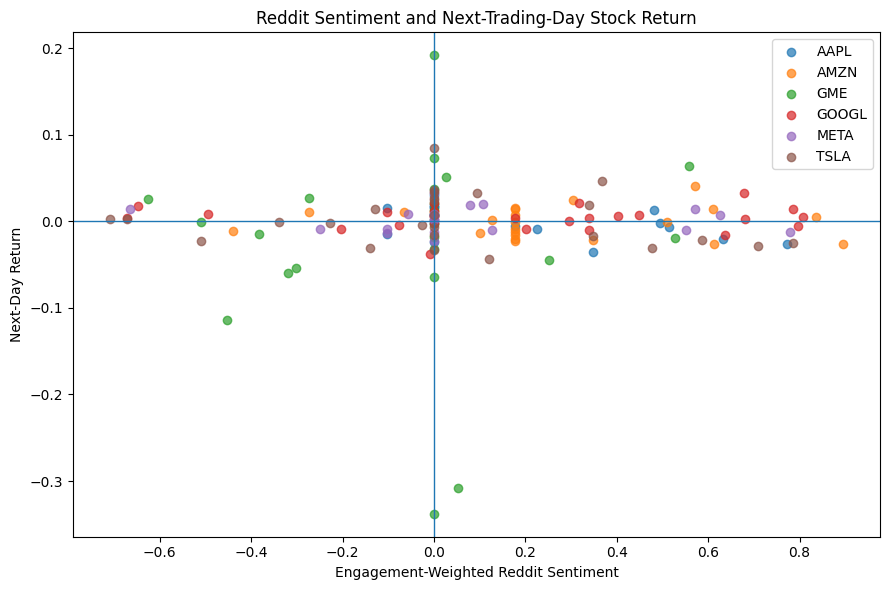

In [824]:
# Display the relationship between Reddit sentiment and subsequent returns

plt.figure(figsize=(9, 6))

for ticker in modelling_data["ticker"].unique():

    ticker_data = modelling_data[
        modelling_data["ticker"] == ticker
    ]

    plt.scatter(
        ticker_data["weighted_sentiment"],
        ticker_data["next_day_return"],
        label=ticker,
        alpha=0.7
    )

plt.axhline(y=0, linewidth=1)
plt.axvline(x=0, linewidth=1)

plt.title("Reddit Sentiment and Next-Trading-Day Stock Return")
plt.xlabel("Engagement-Weighted Reddit Sentiment")
plt.ylabel("Next-Day Return")
plt.legend()
plt.tight_layout()
plt.show()

In [825]:
# Sort the complete dataset chronologically

modelling_data = modelling_data.sort_values(
    "date"
).reset_index(drop=True)

# Use the first 80% of dates for training and the last 20% for testing
unique_dates = np.sort(
    modelling_data["date"].unique()
)

split_position = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[split_position]

train_df = modelling_data[
    modelling_data["date"] < split_date
].copy()

test_df = modelling_data[
    modelling_data["date"] >= split_date
].copy()

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]

y_train_regression = train_df["next_day_return"]
y_test_regression = test_df["next_day_return"]

y_train_classification = train_df["next_day_direction"]
y_test_classification = test_df["next_day_direction"]

print("Chronological split date:", split_date)
print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))
print("Training period:", train_df["date"].min(), "to", train_df["date"].max())
print("Testing period:", test_df["date"].min(), "to", test_df["date"].max())

Chronological split date: 2021-10-20T00:00:00.000000000
Training observations: 111
Testing observations: 25
Training period: 2021-01-12 00:00:00 to 2021-10-19 00:00:00
Testing period: 2021-10-20 00:00:00 to 2021-12-30 00:00:00


In [826]:
def evaluate_regression_model(
    model_name,
    actual_values,
    predicted_values
):
    """
    Calculate the principal regression evaluation metrics.
    """

    mae = mean_absolute_error(
        actual_values,
        predicted_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            predicted_values
        )
    )

    r_squared = r2_score(
        actual_values,
        predicted_values
    )

    # Directional accuracy measures whether the predicted sign is correct
    directional_accuracy = np.mean(
        np.sign(actual_values)
        ==
        np.sign(predicted_values)
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r_squared,
        "Directional_Accuracy": directional_accuracy
    }

In [827]:
# Baseline assumption:
# tomorrow's return will equal today's observed return

baseline_predictions = test_df[
    "daily_return"
].values

regression_results = []

baseline_result = evaluate_regression_model(
    model_name="Naive Previous-Return Baseline",
    actual_values=y_test_regression,
    predicted_values=baseline_predictions
)

regression_results.append(
    baseline_result
)

pd.DataFrame(regression_results).round(5)

,Model,MAE,RMSE,R2,Directional_Accuracy
0,Naive Previous-Return Baseline,0.03133,0.04389,-1.41855,0.44


In [828]:
# Standardisation is included because the predictors use different scales

linear_regression_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]
)

linear_regression_model.fit(
    X_train,
    y_train_regression
)

linear_predictions = (
    linear_regression_model.predict(X_test)
)

linear_result = evaluate_regression_model(
    model_name="Linear Regression",
    actual_values=y_test_regression,
    predicted_values=linear_predictions
)

regression_results.append(
    linear_result
)

pd.DataFrame(regression_results).round(5)

,Model,MAE,RMSE,R2,Directional_Accuracy
0,Naive Previous-Return Baseline,0.03133,0.04389,-1.41855,0.44
1,Linear Regression,0.02975,0.03665,-0.68617,0.28


In [829]:
# Random Forest Model

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train_regression
)

random_forest_predictions = (
    random_forest_model.predict(X_test)
)

random_forest_result = evaluate_regression_model(
    model_name="Random Forest",
    actual_values=y_test_regression,
    predicted_values=random_forest_predictions
)

regression_results.append(
    random_forest_result
)

pd.DataFrame(regression_results).round(5)

,Model,MAE,RMSE,R2,Directional_Accuracy
0,Naive Previous-Return Baseline,0.03133,0.04389,-1.41855,0.44
1,Linear Regression,0.02975,0.03665,-0.68617,0.28
2,Random Forest,0.02946,0.03918,-0.92700,0.36


In [830]:
# XGBoost Model

xgboost_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_STATE
)

xgboost_model.fit(
    X_train,
    y_train_regression
)

xgboost_predictions = (
    xgboost_model.predict(X_test)
)

xgboost_result = evaluate_regression_model(
    model_name="XGBoost",
    actual_values=y_test_regression,
    predicted_values=xgboost_predictions
)

regression_results.append(
    xgboost_result
)

regression_comparison = (
    pd.DataFrame(regression_results)
    .sort_values(
        by="RMSE",
        ascending=True
    )
)

regression_comparison.round(5)

,Model,MAE,RMSE,R2,Directional_Accuracy
3,XGBoost,0.02665,0.03247,-0.32348,0.48
1,Linear Regression,0.02975,0.03665,-0.68617,0.28
2,Random Forest,0.02946,0.03918,-0.92700,0.36
0,Naive Previous-Return Baseline,0.03133,0.04389,-1.41855,0.44


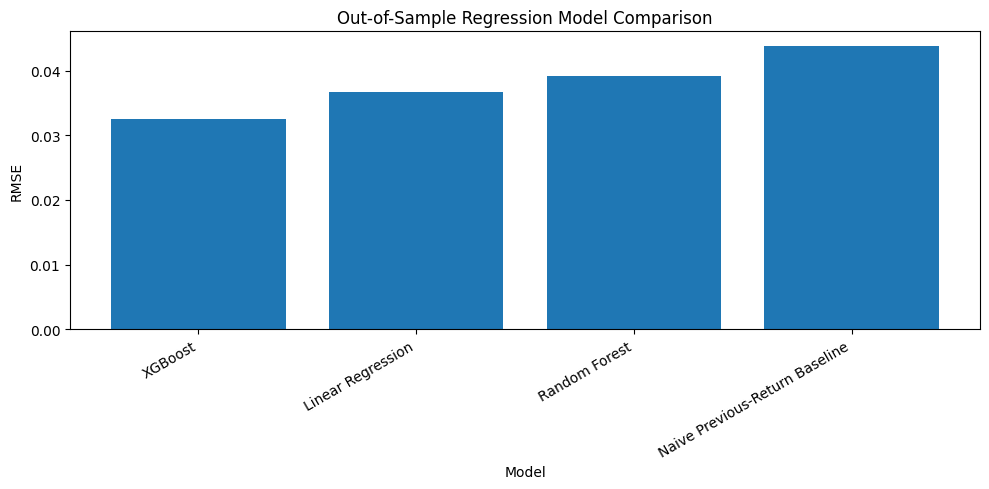

In [831]:
# Compare out-of-sample RMSE across all regression models

plt.figure(figsize=(10, 5))

plt.bar(
    regression_comparison["Model"],
    regression_comparison["RMSE"]
)

plt.title("Out-of-Sample Regression Model Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [832]:
# TimeSeriesSplit preserves temporal order during validation

time_series_cv = TimeSeriesSplit(
    n_splits=4
)

random_forest_parameter_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [2, 3, 5]
}

random_forest_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=random_forest_parameter_grid,
    scoring="neg_root_mean_squared_error",
    cv=time_series_cv,
    n_jobs=-1
)

random_forest_search.fit(
    X_train,
    y_train_regression
)

print(
    "Best Random Forest parameters:",
    random_forest_search.best_params_
)

print(
    "Best cross-validation RMSE:",
    -random_forest_search.best_score_
)

Best Random Forest parameters: {'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 300}
Best cross-validation RMSE: 0.03479991527224218


In [833]:
# Evaluate the tuned model only on the untouched final test period

tuned_random_forest = (
    random_forest_search.best_estimator_
)

tuned_predictions = (
    tuned_random_forest.predict(X_test)
)

tuned_result = evaluate_regression_model(
    model_name="Tuned Random Forest",
    actual_values=y_test_regression,
    predicted_values=tuned_predictions
)

regression_results.append(
    tuned_result
)

regression_comparison = (
    pd.DataFrame(regression_results)
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .sort_values(
        by="RMSE"
    )
)

regression_comparison.round(5)

,Model,MAE,RMSE,R2,Directional_Accuracy
3,XGBoost,0.02665,0.03247,-0.32348,0.48
1,Linear Regression,0.02975,0.03665,-0.68617,0.28
2,Random Forest,0.02946,0.03918,-0.92700,0.36
4,Tuned Random Forest,0.02971,0.04255,-1.27328,0.36
0,Naive Previous-Return Baseline,0.03133,0.04389,-1.41855,0.44


In [834]:
# Use a focused explanatory model to reduce overfitting
# and provide interpretable statistical evidence.

statistical_features = [
    "weighted_sentiment",
    "log_post_volume",
    "daily_return",
    "volatility_5d"
]

X_statistical = modelling_data[
    statistical_features
].copy()

X_statistical = sm.add_constant(
    X_statistical
)

y_statistical = modelling_data[
    "next_day_return"
]

robust_ols_model = sm.OLS(
    y_statistical,
    X_statistical
).fit(
    cov_type="HC3"
)

print(robust_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        next_day_return   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                    0.4476
Date:                Wed, 29 Jul 2026   Prob (F-statistic):              0.774
Time:                        11:43:14   Log-Likelihood:                 232.69
No. Observations:                 136   AIC:                            -455.4
Df Residuals:                     131   BIC:                            -440.8
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0339      0

In [835]:
# Present coefficients and 95% confidence intervals clearly

confidence_intervals = (
    robust_ols_model.conf_int(alpha=0.05)
)

confidence_intervals.columns = [
    "Lower_95_CI",
    "Upper_95_CI"
]

coefficient_table = pd.concat(
    [
        robust_ols_model.params.rename("Coefficient"),
        robust_ols_model.pvalues.rename("P_Value"),
        confidence_intervals
    ],
    axis=1
)

coefficient_table.round(6)

,Coefficient,P_Value,Lower_95_CI,Upper_95_CI
const,0.033886,0.329597,-0.034237,0.102008
weighted_sentiment,0.000154,0.984823,-0.015727,0.016036
log_post_volume,-0.044830,0.283369,-0.126735,0.037074
daily_return,-0.168957,0.270730,-0.469624,0.131710
volatility_5d,-0.034789,0.727929,-0.230792,0.161213


In [836]:
def bootstrap_rmse_interval(
    actual,
    predicted,
    iterations=2000,
    confidence_level=0.95,
    random_state=42
):
    """
    Estimate a bootstrap confidence interval for model RMSE.
    """

    rng = np.random.default_rng(
        random_state
    )

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    bootstrap_scores = []

    for _ in range(iterations):

        sample_indices = rng.integers(
            0,
            len(actual),
            len(actual)
        )

        sampled_actual = actual[
            sample_indices
        ]

        sampled_predicted = predicted[
            sample_indices
        ]

        score = np.sqrt(
            mean_squared_error(
                sampled_actual,
                sampled_predicted
            )
        )

        bootstrap_scores.append(score)

    alpha = 1 - confidence_level

    lower_bound = np.quantile(
        bootstrap_scores,
        alpha / 2
    )

    upper_bound = np.quantile(
        bootstrap_scores,
        1 - alpha / 2
    )

    return lower_bound, upper_bound


rmse_lower, rmse_upper = bootstrap_rmse_interval(
    y_test_regression,
    tuned_predictions
)

print(
    "Tuned Random Forest RMSE 95% confidence interval:",
    round(rmse_lower, 6),
    "to",
    round(rmse_upper, 6)
)

Tuned Random Forest RMSE 95% confidence interval: 0.02462 to 0.058634


In [837]:
# Calculate feature importance using the untouched test data

importance_result = permutation_importance(
    tuned_random_forest,
    X_test,
    y_test_regression,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=RANDOM_STATE
)

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance_Mean": importance_result.importances_mean,
    "Importance_Standard_Deviation": (
        importance_result.importances_std
    )
}).sort_values(
    by="Importance_Mean",
    ascending=False
)

feature_importance

,Feature,Importance_Mean,Importance_Standard_Deviation
1,average_sentiment,0.000049,0.000031
7,sentiment_lag_1,0.000041,0.000124
3,positive_share,0.000025,0.000018
6,log_total_comments,0.000011,0.000222
4,negative_share,0.000006,0.000009
0,weighted_sentiment,0.000004,0.000004
5,log_post_volume,0.000001,0.000099
11,daily_return,-0.000089,0.000120
14,volatility_5d,-0.000097,0.000041
12,return_lag_1,-0.000107,0.000217


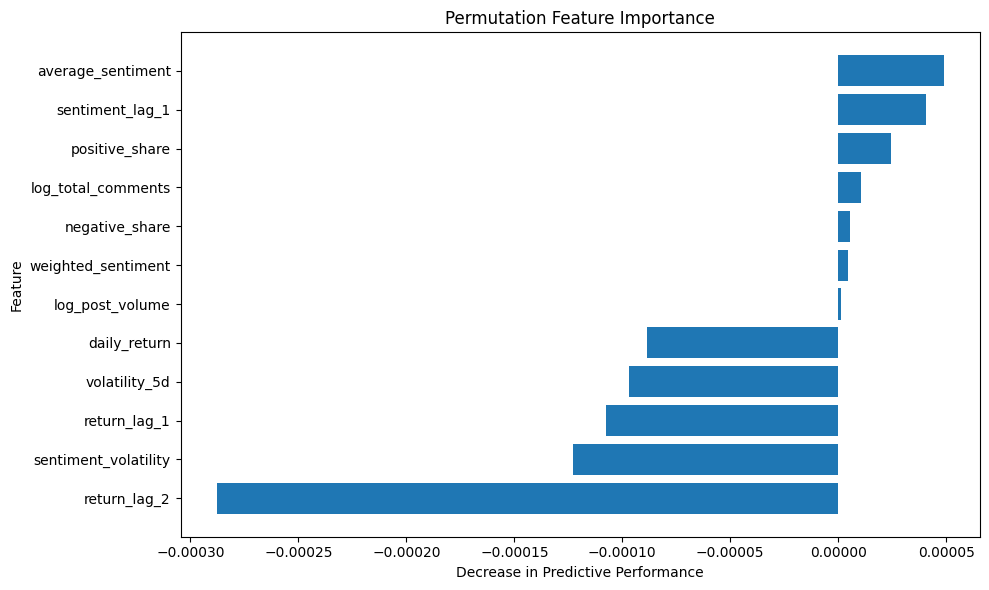

In [838]:
# Display the predictors contributing most to test performance

plot_importance = feature_importance.head(12)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_importance["Feature"][::-1],
    plot_importance["Importance_Mean"][::-1]
)

plt.title("Permutation Feature Importance")
plt.xlabel("Decrease in Predictive Performance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

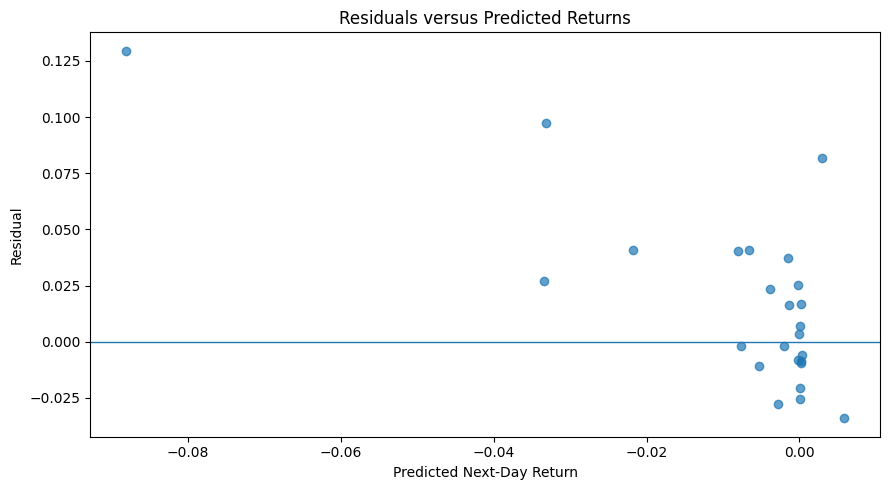

In [839]:
# Calculate residuals for the tuned regression model

residuals = (
    y_test_regression.values
    - tuned_predictions
)

plt.figure(figsize=(9, 5))

plt.scatter(
    tuned_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Residuals versus Predicted Returns")
plt.xlabel("Predicted Next-Day Return")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

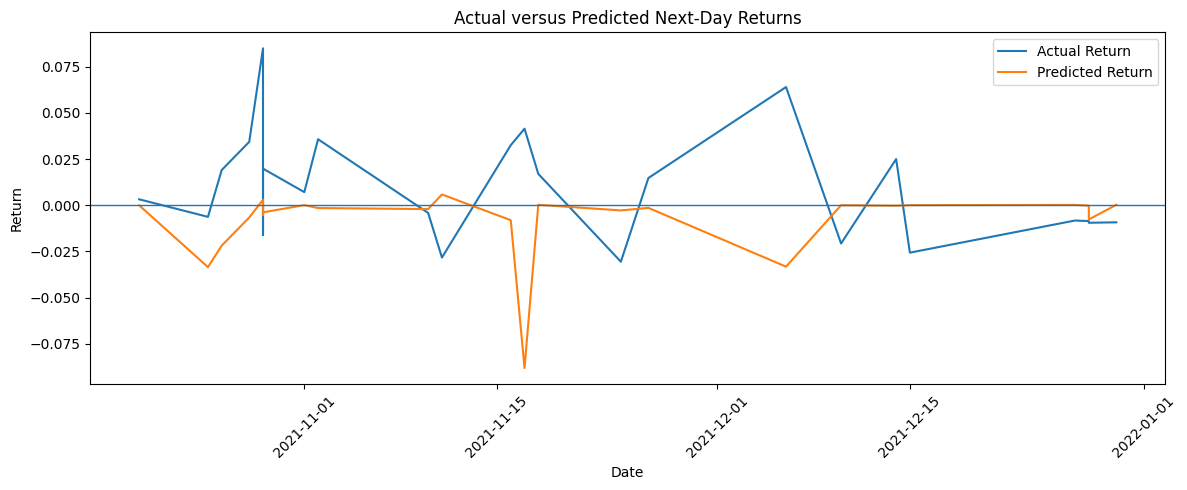

In [840]:
# Compare predictions with observed next-day returns over time

prediction_output = test_df[
    ["date", "ticker", "next_day_return"]
].copy()

prediction_output["predicted_return"] = (
    tuned_predictions
)

prediction_output = prediction_output.sort_values(
    "date"
)

plt.figure(figsize=(12, 5))

plt.plot(
    prediction_output["date"],
    prediction_output["next_day_return"],
    label="Actual Return"
)

plt.plot(
    prediction_output["date"],
    prediction_output["predicted_return"],
    label="Predicted Return"
)

plt.axhline(y=0, linewidth=1)

plt.title("Actual versus Predicted Next-Day Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [841]:
def evaluate_classifier(
    model_name,
    actual,
    predicted
):
    """
    Calculate binary classification metrics.
    """

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            actual,
            predicted
        ),
        "Precision": precision_score(
            actual,
            predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            actual,
            predicted,
            zero_division=0
        ),
        "F1_Score": f1_score(
            actual,
            predicted,
            zero_division=0
        )
    }

In [842]:
# Predict the majority training class for every test observation

majority_class = (
    y_train_classification.mode()[0]
)

baseline_class_predictions = np.full(
    shape=len(y_test_classification),
    fill_value=majority_class
)

classification_results = []

classification_results.append(
    evaluate_classifier(
        "Majority-Class Baseline",
        y_test_classification,
        baseline_class_predictions
    )
)

pd.DataFrame(classification_results).round(4)

,Model,Accuracy,Precision,Recall,F1_Score
0,Majority-Class Baseline,0.52,0.52,1.0,0.6842


In [843]:
# Logistic Regression provides an interpretable directional model

logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train_classification
)

logistic_predictions = logistic_model.predict(
    X_test
)

classification_results.append(
    evaluate_classifier(
        "Logistic Regression",
        y_test_classification,
        logistic_predictions
    )
)

pd.DataFrame(classification_results).round(4)

,Model,Accuracy,Precision,Recall,F1_Score
0,Majority-Class Baseline,0.52,0.5200,1.0000,0.6842
1,Logistic Regression,0.44,0.4615,0.4615,0.4615


In [844]:
# Train a nonlinear directional classifier

random_forest_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_classifier.fit(
    X_train,
    y_train_classification
)

forest_class_predictions = (
    random_forest_classifier.predict(X_test)
)

classification_results.append(
    evaluate_classifier(
        "Random Forest Classifier",
        y_test_classification,
        forest_class_predictions
    )
)

classification_comparison = (
    pd.DataFrame(classification_results)
    .sort_values(
        by="F1_Score",
        ascending=False
    )
)

classification_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1_Score
0,Majority-Class Baseline,0.52,0.5200,1.0000,0.6842
2,Random Forest Classifier,0.48,0.5000,0.5385,0.5185
1,Logistic Regression,0.44,0.4615,0.4615,0.4615


In [845]:
# Display the confusion matrix for the Random Forest classifier

confusion = confusion_matrix(
    y_test_classification,
    forest_class_predictions
)

confusion_table = pd.DataFrame(
    confusion,
    index=[
        "Actual Down/No Rise",
        "Actual Rise"
    ],
    columns=[
        "Predicted Down/No Rise",
        "Predicted Rise"
    ]
)

confusion_table

,Predicted Down/No Rise,Predicted Rise
Actual Down/No Rise,5,7
Actual Rise,6,7


In [846]:
# Report precision, recall and F1-score for both market directions

print(
    classification_report(
        y_test_classification,
        forest_class_predictions,
        target_names=[
            "Down or Unchanged",
            "Up"
        ],
        zero_division=0
    )
)

                   precision    recall  f1-score   support

Down or Unchanged       0.45      0.42      0.43        12
               Up       0.50      0.54      0.52        13

         accuracy                           0.48        25
        macro avg       0.48      0.48      0.48        25
     weighted avg       0.48      0.48      0.48        25



In [847]:
# Market-only features represent a benchmark without Reddit information

market_only_features = [
    "daily_return",
    "return_lag_1",
    "return_lag_2",
    "volatility_5d"
]

# Combined features include Reddit sentiment and market variables
combined_features = feature_columns

market_only_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

combined_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit the benchmark model
market_only_model.fit(
    train_df[market_only_features],
    y_train_regression
)

market_only_predictions = (
    market_only_model.predict(
        test_df[market_only_features]
    )
)

# Fit the model containing Reddit sentiment
combined_model.fit(
    train_df[combined_features],
    y_train_regression
)

combined_predictions = (
    combined_model.predict(
        test_df[combined_features]
    )
)

incremental_comparison = pd.DataFrame([
    evaluate_regression_model(
        "Market Variables Only",
        y_test_regression,
        market_only_predictions
    ),
    evaluate_regression_model(
        "Market + Reddit Sentiment",
        y_test_regression,
        combined_predictions
    )
])

incremental_comparison.round(5)

,Model,MAE,RMSE,R2,Directional_Accuracy
0,Market Variables Only,0.02598,0.03463,-0.5052,0.36
1,Market + Reddit Sentiment,0.02946,0.03918,-0.9270,0.36


In [848]:
# Calculate percentage change in prediction error

market_rmse = incremental_comparison.loc[
    incremental_comparison["Model"]
    == "Market Variables Only",
    "RMSE"
].iloc[0]

combined_rmse = incremental_comparison.loc[
    incremental_comparison["Model"]
    == "Market + Reddit Sentiment",
    "RMSE"
].iloc[0]

rmse_improvement_percentage = (
    (market_rmse - combined_rmse)
    / market_rmse
) * 100

print(
    "RMSE improvement from adding Reddit sentiment:",
    round(rmse_improvement_percentage, 2),
    "%"
)

RMSE improvement from adding Reddit sentiment: -13.15 %


In [849]:
# Test whether performance is consistent across companies

stock_level_results = []

test_results_by_stock = test_df[
    ["date", "ticker", "next_day_return"]
].copy()

test_results_by_stock["prediction"] = (
    combined_predictions
)

for ticker in test_results_by_stock[
    "ticker"
].unique():

    ticker_test = test_results_by_stock[
        test_results_by_stock["ticker"] == ticker
    ]

    if len(ticker_test) < 3:
        continue

    ticker_metrics = evaluate_regression_model(
        model_name=ticker,
        actual_values=ticker_test[
            "next_day_return"
        ],
        predicted_values=ticker_test[
            "prediction"
        ]
    )

    ticker_metrics["Observations"] = len(
        ticker_test
    )

    stock_level_results.append(
        ticker_metrics
    )

stock_level_performance = pd.DataFrame(
    stock_level_results
)

stock_level_performance.round(5)

,Model,MAE,RMSE,R2,Directional_Accuracy,Observations
0,META,0.01426,0.01763,-1.43921,0.50000,4
1,TSLA,0.03897,0.04383,-0.60403,0.44444,9
2,AMZN,0.03055,0.03924,-1.34810,0.20000,5
3,AAPL,0.01281,0.01413,-0.00294,0.50000,4


In [850]:
# Test whether Reddit sentiment works independently


sentiment_only_features = [
    "weighted_sentiment",
    "average_sentiment",
    "sentiment_volatility",
    "positive_share",
    "negative_share",
    "log_post_volume",
    "log_total_comments",
    "sentiment_lag_1",
    "sentiment_lag_2",
    "sentiment_rolling_3",
    "sentiment_rolling_5"
]

sentiment_only_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

sentiment_only_model.fit(
    train_df[sentiment_only_features],
    y_train_regression
)

sentiment_only_predictions = (
    sentiment_only_model.predict(
        test_df[sentiment_only_features]
    )
)

signal_comparison = pd.DataFrame([
    evaluate_regression_model(
        "Sentiment Only",
        y_test_regression,
        sentiment_only_predictions
    ),
    evaluate_regression_model(
        "Market Only",
        y_test_regression,
        market_only_predictions
    ),
    evaluate_regression_model(
        "Sentiment + Market",
        y_test_regression,
        combined_predictions
    )
]).sort_values("RMSE")

signal_comparison.round(5)

,Model,MAE,RMSE,R2,Directional_Accuracy
1,Market Only,0.02598,0.03463,-0.50520,0.36
2,Sentiment + Market,0.02946,0.03918,-0.92700,0.36
0,Sentiment Only,0.03101,0.04216,-1.23102,0.44
